## 1. What this notebook computes

This notebook derives the field equations of the two fields of the book in the
author's primordial gravitational field, exactly, with the computer doing every
step of algebra that a person would do by hand. It

- reads the author's gamma matrices and the matrix $C$ from the Revision record and
  checks the Clifford relation;
- builds the author's metric from its diagonal frame (vielbein), checks that the
  volume factor is $\sqrt{|g|} = \cos z$, and plots the scale factors of 3-space
  and of the three deflating extra times;
- computes the 25 nonzero Christoffel symbols, the 12 nonzero components of the
  canonical spin connection and the spinor connection $\Omega_\mu$;
- shows that the spin-connection term of the field equation is
  $\gamma^\mu\Omega_\mu = 3H\gamma^{(x_8)}$: the time terms of the three inflating
  and the three deflating directions cancel, the hidden-direction terms add up;
- writes the Lagrangian of both fields in an exact "jet" algebra: 392 monomials
  for dirac16complex (anticommuting) and 408 for dirac16complex00 (commuting), the
  difference being 16 squares $(\bar\Psi_A\Psi_B)^2$ that vanish for Grassmann
  numbers;
- proves that the Lagrangian is real, that it differs from the unsymmetrised form
  by a total divergence, and that the spin connection drops out of it in this
  metric;
- derives the 16 Euler-Lagrange equations for both statistics and shows that they
  are the same: $\gamma^\mu D_\mu\Psi = (m + \lambda S)\Psi$;
- writes them out in the author's metric and compares every one of the 16 component
  equations term by term with the Revision formula record
  Revision/theory/field-theory.json;
- checks two more forms of the same equations: the chiral block form (each
  equation relates the two halves of $\Psi$) and the evolution form, which gives
  the time derivative $\partial_4\Psi$ from the field at one time;
- verifies an exact family of solutions and shows numerically that it fails when
  the spin-connection term $3H\gamma^{(x_8)}$ is left out.

Every result that the Revision record also contains is checked against it; such a
PASS line is followed by a line "reproduces <record file>, check <name>".

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 07b (The Euler-Lagrange equations in the author's metric) is the file
`Revision/textbook/notebooks/07b_euler_lagrange_metric.ipynb` of the repository
Dirac_claude. It builds the author's primordial metric, its diagonal frame, Christoffel
symbols and canonical spin connection from the Revision gamma matrices with exact
computer algebra, shows that the spin-connection term of the field equation is 3 H
gamma^(x8) because the time terms of the three inflating and the three deflating
directions cancel, writes the Lagrangian of both fields in an exact jet algebra (392
monomials for dirac16complex, 408 for dirac16complex00), proves that it is real, derives
the 16 Euler-Lagrange equations for both statistics, compares them term by term with the
Revision formula record, checks their chiral block form and their evolution form,
verifies an exact family of solutions, and draws six teaching plots. It needs a computer
with Windows 11, macOS or Linux, an internet connection for the installation, the program
Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these
packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib
3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and
nbconvert 7.16.6. The notebook itself imports numpy, sympy and matplotlib; the other
packages run Jupyter, the program that shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 07b_euler_lagrange_metric.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 30 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 07b_euler_lagrange_metric.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
07b_euler_lagrange_metric.ipynb` (in the same folder, without running the cells again) to
read the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/07b.captions.json`
- `Revision/textbook/figures/07b_1_scale_factors.png`
- `Revision/textbook/figures/07b_2_gamma_omega_per_direction.png`
- `Revision/textbook/figures/07b_3_lagrangian_monomials.png`
- `Revision/textbook/figures/07b_4_coupling_map.png`
- `Revision/textbook/figures/07b_5_exact_solutions.png`
- `Revision/textbook/figures/07b_6_residuals.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS all 6 figure files of this notebook exist
    ALL 47 CHECKS PASSED (notebook 07b)

and the notebook must show 6 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/07b_euler_lagrange_metric.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "ValueError: ... is not a passing check of Revision/theory/reports/..." or a check that
  names Revision/theory/field-theory.json fails: the Revision record files of your copy
  of the repository differ from the committed ones; restore them with the command below
  (run in the repository folder) and run the notebook again.

      git restore Revision/theory Revision/algebra

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 07b (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 07b (The Euler-Lagrange equations in the author's metric) is the file
# Revision/textbook/notebooks/07b_euler_lagrange_metric.ipynb of the repository
# Dirac_claude. It builds the author's primordial metric, its diagonal frame, Christoffel
# symbols and canonical spin connection from the Revision gamma matrices with exact
# computer algebra, shows that the spin-connection term of the field equation is 3 H
# gamma^(x8) because the time terms of the three inflating and the three deflating
# directions cancel, writes the Lagrangian of both fields in an exact jet algebra (392
# monomials for dirac16complex, 408 for dirac16complex00), proves that it is real,
# derives the 16 Euler-Lagrange equations for both statistics, compares them term by term
# with the Revision formula record, checks their chiral block form and their evolution
# form, verifies an exact family of solutions, and draws six teaching plots. It needs a
# computer with Windows 11, macOS or Linux, an internet connection for the installation,
# the program Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5)
# with these packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0,
# matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0
# and nbconvert 7.16.6. The notebook itself imports numpy, sympy and matplotlib; the
# other packages run Jupyter, the program that shows and runs notebooks. It does not need
# Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 07b_euler_lagrange_metric.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 30
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 07b_euler_lagrange_metric.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 07b_euler_lagrange_metric.ipynb (in the same folder, without running the cells again)
# to read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/07b.captions.json
# - Revision/textbook/figures/07b_1_scale_factors.png
# - Revision/textbook/figures/07b_2_gamma_omega_per_direction.png
# - Revision/textbook/figures/07b_3_lagrangian_monomials.png
# - Revision/textbook/figures/07b_4_coupling_map.png
# - Revision/textbook/figures/07b_5_exact_solutions.png
# - Revision/textbook/figures/07b_6_residuals.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS all 6 figure files of this notebook exist
#     ALL 47 CHECKS PASSED (notebook 07b)
#
# and the notebook must show 6 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/07b_euler_lagrange_metric.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "ValueError: ... is not a passing check of Revision/theory/reports/..." or a check
#   that names Revision/theory/field-theory.json fails: the Revision record files of your
#   copy of the repository differ from the committed ones; restore them with the command
#   below (run in the repository folder) and run the notebook again.
#     git restore Revision/theory Revision/algebra
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "07b"  # this notebook: chapter 07, example b


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 07b complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Coordinates** $x_1, \dots, x_8$, named as the author names them: $x_1, x_2,
  x_3$ ordinary 3-space; $x_4$ the time; $x_5, x_6, x_7$ the three **extra
  times** (time-like directions that shrink, "deflate", as $a_4$ grows); $x_8$ the
  **hidden** space direction. In the program they are list positions 0 to 7.
- **Metric** $g_{\mu\nu}$: the table that gives lengths and time intervals,
  $ds^2 = \sum g_{\mu\nu} dx_\mu dx_\nu$. The author's metric is diagonal. Its
  **signature** (4,4): four space-like directions ($x_1, x_2, x_3, x_8$, positive
  entries) and four time-like ones ($x_4, \dots, x_7$, negative entries).
- $z = 6Hx_8$, with the author's constant $H > 0$ and $0 < z < \pi/2$; $a_4(x_4)$ is
  the free function of time in the metric; $a_4' = da_4/dx_4$.
- **Scale factor**: the number by which a coordinate distance is multiplied to give
  a real (proper) distance: $e^{a_4}\sin^{1/6}z$ for 3-space, $e^{-a_4}\sin^{1/6}z$
  for the extra times. When $a_4$ grows, 3-space inflates and the extra times
  deflate.
- **Vielbein (frame)** $e^a{}_\mu = f_a\delta^a_\mu$: a set of eight local unit
  directions; here simply the square roots $f_a = \sqrt{|g_{aa}|}$.
- **Frame gamma matrices** $\gamma^{(a)}$: the author's eight real $16\times16$
  matrices with $\gamma^{(a)}\gamma^{(b)} + \gamma^{(b)}\gamma^{(a)} = 2\eta^{ab}$,
  $\eta = \mathrm{diag}(1,1,1,-1,-1,-1,-1,1)$. **Coordinate gammas** $\gamma^\mu =
  \gamma^{(\mu)}/f_\mu$.
- **Christoffel symbols** $\Gamma^\lambda{}_{\mu\nu}$: the numbers that say how the
  coordinate directions turn from point to point.
- **Canonical spin connection** $\omega_{\mu ab}$ and **spinor connection**
  $\Omega_\mu = \frac12\omega_{\mu ab}S^{ab}$, $S^{ab} = \frac14[\gamma^{(a)},
  \gamma^{(b)}]$: they say how the frame turns, and how a spinor must be turned
  with it. **Covariant derivative** $D_\mu\Psi = \partial_\mu\Psi + \Omega_\mu\Psi$.
- **Lagrangian density** $L$: the function whose integral (the action) must not
  change to first order when the field is varied; that requirement is the
  **Euler-Lagrange equation**, the field equation.
- **Statistics**: whether the components commute (dirac16complex00) or
  anticommute (dirac16complex, Grassmann numbers).
- **Jet**: the value of a field component and its derivatives at one point,
  treated as independent symbols ($\psi_A$, $\partial_\mu\psi_A$, ...). The
  **total derivative** $d/dx_\mu$ acts on jets by raising the derivative order.
- **Coefficient ring**: the symbols $E = e^{a_4}$, $s = \sin^{1/6}z$, $c = \cos z$,
  $A_1 = a_4'$ and the second and third derivatives $A_2 = a_4^{\prime\prime}$,
  $A_3 = a_4^{\prime\prime\prime}$, together with $H$, $m$, $\lambda$, in which
  every coefficient is written; with the rule $c^2 = 1 - s^{12}$ it allows an
  exact test whether an expression is zero.
- **Monomial**: a product of jets with a coefficient, such as
  $E\,s\,\chi_3\,\partial_1\psi_7$.
- **On shell**: on solutions of the field equation.

## 4. The physical and mathematical situation

**The author's metric** (Revision/SPEC.md, section 1), $z = 6Hx_8 \in (0,
\pi/2)$:

$$ds^2 = e^{2a_4}\sin^{1/3}z\,(dx_1^2 + dx_2^2 + dx_3^2) - dx_4^2
- e^{-2a_4}\sin^{1/3}z\,(dx_5^2 + dx_6^2 + dx_7^2) + \cot^2 z\, dx_8^2 .$$

3-space ($x_1, x_2, x_3$) has the scale factor $e^{a_4}\sin^{1/6}z$, the three
extra times ($x_5, x_6, x_7$) the scale factor $e^{-a_4}\sin^{1/6}z$: when $a_4$
increases, 3-space inflates and the extra times DEFLATE exponentially. Every
equation of this notebook holds for every function $a_4(x_4)$. Only the plots use a
definite history, the linear member $a_4 = AHx_4$ with $A = 1$ and $H = 1$; this
history is prescribed (a choice made for the picture, deflation being the choice of
sign $A > 0$), not a result.

**The two fields** have the same Lagrangian (Revision/SPEC.md, section 3):

$$L = \sqrt{|g|}\,\Big[\tfrac12\big(\bar\Psi\gamma^\mu D_\mu\Psi -
(D_\mu\bar\Psi)\gamma^\mu\Psi\big) - mS - \tfrac{\lambda}{2}S^2\Big],\quad
\bar\Psi = \Psi^\dagger C,\quad S = \bar\Psi\Psi,\quad D_\mu\bar\Psi =
\partial_\mu\bar\Psi - \bar\Psi\Omega_\mu .$$

For dirac16complex the 16 components are complex Grassmann numbers, for
dirac16complex00 ordinary complex numbers.

**What we expect.** Varying $\Psi^\dagger$ should give the field equation
$\gamma^\mu D_\mu\Psi = (m + \lambda S)\Psi$ for both statistics, and in the
author's metric

$$e^{-a_4}\sin^{-1/6}z\sum_{i=1}^{3}\gamma^{(x_i)}\partial_i\Psi
+ \gamma^{(x_4)}\partial_4\Psi + e^{a_4}\sin^{-1/6}z\sum_{t=5}^{7}
\gamma^{(x_t)}\partial_t\Psi + \tan z\,\gamma^{(x_8)}\partial_8\Psi
+ 3H\gamma^{(x_8)}\Psi = (m + \lambda S)\Psi .$$

**How the computer proves it.** Every coefficient is written with the symbols of
the coefficient ring; derivatives along $x_4$ and $x_8$ follow fixed rules
(section 6); and a coefficient is exactly zero when its numerator vanishes after
$c^2$ is replaced by $1 - s^{12}$. The field components and their derivatives at a
point are the generators of a jet algebra that can be commuting or anticommuting
(section 12). Nothing is approximated, except in the two numerical plots at the end.

## 5. The gamma matrices and $C$ from the Revision record

The next cell imports the packages and wraps the set-up cell's `check` so that a
PASS line and the line "reproduces ..." that follows it are printed by one single
`print` call (Jupyter sends printed text in pieces; two separate prints can arrive
in two pieces, and the book's tools then do not see that the two lines belong
together). It then reads the eight frame gamma matrices
$\gamma^{(x_1)}, \dots, \gamma^{(x_8)}$ and the matrix $C = \gamma^{(x_8)}
\gamma^{(x_1)}\gamma^{(x_2)}\gamma^{(x_3)}$ from Revision/algebra/gammas.json as
exact sympy matrices, builds the 28 spin generators $S^{ab} = \frac14(\gamma^{(a)}
\gamma^{(b)} - \gamma^{(b)}\gamma^{(a)})$, and defines a helper that looks up a
check of a Revision report and makes sure that its verdict is PASS. It then checks
the Clifford relation for all 64 pairs and the properties of $C$.

In [2]:
import contextlib  # redirect printed text into a buffer
import io  # an in-memory text file (the buffer)
import re  # regular expressions: used to read the Wolfram formula record

import numpy as np  # numbers for the plots
import sympy as sp  # exact algebra

check_of_the_setup = check  # the helper check of the set-up cell


def check(condition, name, record=None):
    """The set-up cell's check, with its PASS line and its "reproduces" line
    printed by ONE print call, so that Jupyter delivers them together."""
    buffer = io.StringIO()
    with contextlib.redirect_stdout(buffer):  # collect what check prints
        check_of_the_setup(condition, name, record)
    print(buffer.getvalue(), end="")  # and print it in one piece


GAMMAS = "Revision/algebra/gammas.json"
FORMULAS = "Revision/theory/field-theory.json"
PYREP = "Revision/theory/reports/python-field-theory.json"
WLREP = "Revision/theory/reports/wolfram-field-theory.json"
SCOPE = "Revision/theory/reports/python-scope.json"


def revision_check(report, name):
    """The check called name of the Revision report (a JSON file): a dictionary
    with its name, verdict and detail; stops if it is missing or not PASS."""
    data = json.loads(repository_file(report).read_text(encoding="utf-8"))
    found = [item for item in data["checks"] if item["name"] == name]
    if len(found) != 1 or found[0]["verdict"].upper() != "PASS":
        raise ValueError(f"{name} is not a passing check of {report}")
    return found[0]


def reproduces(report, name):
    """The text "<report>, check <name>" for a PASS line, after making sure that
    the Revision report contains the check name with the verdict PASS."""
    revision_check(report, name)
    return f"{report}, check {name}"


fixture = json.loads(repository_file(GAMMAS).read_text(encoding="utf-8"))
G = [sp.Matrix(g) for g in fixture["gamma"]]  # gamma^(x1) .. gamma^(x8), integers
C = sp.Matrix(fixture["C"])  # the author's sigma16
ETA = [1, 1, 1, -1, -1, -1, -1, 1]  # eta in the order x1 .. x8
I16, Z16 = sp.eye(16), sp.zeros(16, 16)
SAB = [[(G[a] * G[b] - G[b] * G[a]) / 4 for b in range(8)] for a in range(8)]
X4, X8 = 3, 7  # list positions of the time x4 and of the hidden direction x8
NAMES = ["x1", "x2", "x3", "x4", "x5", "x6", "x7", "x8"]
clifford = all(G[a] * G[b] + G[b] * G[a] == 2 * (ETA[a] if a == b else 0) * I16
               for a in range(8) for b in range(8))
check(clifford, "{gamma^a, gamma^b} = 2 eta^ab I16 for all 64 pairs",
      record=reproduces(PYREP, "clifford_relations"))
c_ok = (C == G[7] * G[0] * G[1] * G[2] and C.T == C and C * C == I16
        and all((C * g).T == -(C * g) for g in G))
check(c_ok, "C = gamma^(x8) gamma^(x1) gamma^(x2) gamma^(x3), symmetric, C^2 = 1, "
      "every C gamma^a antisymmetric", record=reproduces(PYREP, "C_properties"))

PASS {gamma^a, gamma^b} = 2 eta^ab I16 for all 64 pairs
     reproduces Revision/theory/reports/python-field-theory.json, check
    clifford_relations
PASS C = gamma^(x8) gamma^(x1) gamma^(x2) gamma^(x3), symmetric, C^2 = 1, every C gamma^a
    antisymmetric
     reproduces Revision/theory/reports/python-field-theory.json, check C_properties


## 6. Exact symbols for the metric functions (the coefficient ring)

Every coefficient will be written with the symbols $E = e^{a_4(x_4)}$, $s =
\sin^{1/6}z$, $c = \cos z$, $A_1 = a_4'$, $A_2 = a_4^{\prime\prime}$, $A_3 =
a_4^{\prime\prime\prime}$, $H$, $m$ and $\lambda$. Their derivatives follow from
the chain rule, line by line:

- $\partial_4 E = e^{a_4}a_4' = E A_1$, $\partial_4 A_1 = A_2$, $\partial_4 A_2 =
  A_3$ (the derivative of $e^{a_4(x_4)}$ is $e^{a_4}$ times the derivative of the
  exponent);
- $\partial_8 s = \frac16\sin^{-5/6}z\,\cos z \cdot 6H = H c/s^5$ (the power rule,
  then the derivative $\cos z$ of $\sin z$, then $dz/dx_8 = 6H$, and finally
  $\sin^{-5/6}z = s^{-5}$);
- $\partial_8 c = -\sin z \cdot 6H = -6Hs^6$ (because $\sin z = s^6$);
- no symbol depends on $x_1, x_2, x_3, x_5, x_6, x_7$.

The function `cd(expression, mu)` applies these rules (the product and chain rules
are done by sympy's `diff`). Since $\cos^2z + \sin^2z = 1$, the symbols obey
$c^2 = 1 - s^{12}$; the function `is_zero` brings an expression to one fraction and
replaces $c^2$ by $1 - s^{12}$ in its numerator (by polynomial division), which
decides exactly whether it is zero. The function `to_physical` turns ring
expressions back into functions of $x_4$ and $x_8$. The cell checks the derivative
rules against sympy's own derivatives of the physical functions.

In [3]:
E, s, c = sp.symbols("E s c", positive=True)  # e^a4, sin(z)^(1/6), cos z
A1, A2, A3 = sp.symbols("A1 A2 A3", real=True)  # 1st, 2nd, 3rd derivative of a4
H = sp.Symbol("H", positive=True)  # the author's constant
m, lam = sp.symbols("m lambda", real=True)  # the mass and the coupling


def cd(expression, mu):
    """The derivative of a ring expression along coordinate mu (0 .. 7)."""
    expression = sp.sympify(expression)
    if mu == X4:
        return (sp.diff(expression, E) * E * A1 + sp.diff(expression, A1) * A2
                + sp.diff(expression, A2) * A3)
    if mu == X8:
        return (sp.diff(expression, s) * H * c / s**5
                + sp.diff(expression, c) * (-6 * H * s**6))
    return sp.Integer(0)  # nothing depends on x1, x2, x3, x5, x6, x7


def is_zero(expression):
    """Exact test: the numerator vanishes after c^2 -> 1 - s^12."""
    numerator, _ = sp.fraction(sp.together(sp.sympify(expression)))
    numerator = sp.expand(numerator)
    if numerator == 0:
        return True
    remainder = sp.rem(sp.Poly(numerator, c), sp.Poly(c**2 - 1 + s**12, c))
    return sp.expand(remainder.as_expr()) == 0


x4, x8 = sp.symbols("x4 x8", real=True)
a4 = sp.Function("a4")(x4)  # the free function of the metric
z = 6 * H * x8


def to_physical(expression):
    """Ring symbols -> the functions they stand for."""
    return sp.sympify(expression).subs(
        {E: sp.exp(a4), s: sp.sin(z) ** sp.Rational(1, 6), c: sp.cos(z),
         A1: a4.diff(x4), A2: a4.diff(x4, 2), A3: a4.diff(x4, 3)})


rules_ok = all(
    sp.simplify(to_physical(cd(v, mu)) - sp.diff(to_physical(v), variable)) == 0
    for v in (E, s, c, A1, A2) for mu, variable in ((X4, x4), (X8, x8)))
check(rules_ok, "the derivative rules of the ring agree with sympy's derivatives")
check(is_zero(c**2 + s**12 - 1) and not is_zero(c) and not is_zero(s - c),
      "the exact zero test: c^2 + s^12 - 1 is zero, c and s - c are not")

PASS the derivative rules of the ring agree with sympy's derivatives
PASS the exact zero test: c^2 + s^12 - 1 is zero, c and s - c are not


## 7. The metric, its frame and the volume factor

The diagonal frame has $f_1 = f_2 = f_3 = Es$, $f_4 = 1$, $f_5 = f_6 = f_7 = s/E$,
$f_8 = c/s^6 = \cot z$, and the metric is $g_{aa} = \eta_{aa}f_a^2$. The volume
factor is the product of the $f_a$, worked out line by line:

$$\sqrt{|g|} = f_1 f_2 f_3 \cdot f_4 \cdot f_5 f_6 f_7 \cdot f_8
= E^3s^3 \cdot 1 \cdot \frac{s^3}{E^3} \cdot \frac{c}{s^6} = c = \cos z .$$

The first equality: for a diagonal metric $|\det g|$ is the product of the
$f_a^2$; the second inserts the $f_a$; the third cancels $E^3$ against $E^{-3}$
and $s^6$ against $s^{-6}$. The inflation $E^3$ of 3-space and the deflation
$E^{-3}$ of the extra times compensate: the 7-volume does not depend on time. The
next cell checks that the frame gives the author's metric entry by entry and that
$\sqrt{|g|} = \cos z$.

In [4]:
f = [E * s] * 3 + [sp.Integer(1)] + [s / E] * 3 + [c / s**6]  # the frame factors
g = [ETA[a] * f[a] ** 2 for a in range(8)]  # the diagonal metric entries
sqrt_g = sp.prod(f)  # the volume factor
third = sp.sin(z) ** sp.Rational(1, 3)
author = ([sp.exp(2 * a4) * third] * 3 + [-1] + [-sp.exp(-2 * a4) * third] * 3
          + [sp.cot(z) ** 2])  # the author's metric, typed from Revision/SPEC.md
check(all(sp.simplify(to_physical(g[a]) - author[a]) == 0 for a in range(8)),
      "the diagonal frame reproduces the author's metric entry by entry",
      record=reproduces(PYREP, "metric_from_vielbein_equals_SPEC"))
say(f"sqrt|g| = {sqrt_g} (ring) = {to_physical(sqrt_g)}")
check(sqrt_g == c, "sqrt|g| = cos z, independent of x4",
      record=reproduces(WLREP, "sqrt_det_g_is_cos_z"))

PASS the diagonal frame reproduces the author's metric entry by entry
     reproduces Revision/theory/reports/python-field-theory.json, check
    metric_from_vielbein_equals_SPEC
sqrt|g| = c (ring) = cos(6*H*x8)
PASS sqrt|g| = cos z, independent of x4
     reproduces Revision/theory/reports/wolfram-field-theory.json, check
    sqrt_det_g_is_cos_z


The formula record Revision/theory/field-theory.json stores the formulas of the
Wolfram verifier as text in the Wolfram Language (for example
`E^a4[x4]*Sin[6*H*x8]^(1/6)`). The next cell defines a small translator: it
rewrites such a text into sympy syntax (square brackets to round ones, `^` to
`**`, `Sin` to `sin`, `a4[x4]` to a symbol), lets sympy read it, and then puts it
into the ring: $a_4 \to \ln E$ (so $e^{a_4} \to E$), $\sin z \to s^6$, $\cos z
\to c$, $\tan z \to s^6/c$, $\cot z \to c/s^6$, $\sec z \to 1/c$, $\csc z \to
1/s^6$ and $\csc 2z \to 1/(2s^6c)$ (from $\sin 2z = 2\sin z\cos z$). Then a record
formula and our own result can be compared with `is_zero`. The cell compares the
frame and the volume factor with the record.

In [5]:
record = {item["key"]: item["wl"] for item in
          json.loads(repository_file(FORMULAS).read_text(encoding="utf-8"))["formulas"]}
a4x, A1w = sp.symbols("a4x A1w", real=True)  # a4(x4) and a4'(x4) in the record


def from_wolfram(text):
    """Read a Wolfram InputForm text of the formula record into sympy."""
    t = text.replace("Derivative[1][a4][x4]", "A1w").replace("a4[x4]", "a4x")
    t = re.sub(r'dd\["x(\d)",\s*Psi\[(\d+)\]\]', r"d\1_\2", t)  # d_a Psi_B
    t = re.sub(r"Psi\[(\d+)\]", r"P\1", t)  # Psi_B
    for name in ("Sin", "Cos", "Tan", "Cot", "Sec", "Csc"):
        t = t.replace(name + "[", name.lower() + "(")
    t = t.replace("[", "(").replace("]", ")").replace("{", "[").replace("}", "]")
    t = t.replace("^", "**")
    names = {"E": sp.E, "H": H, "x8": x8, "a4x": a4x, "A1w": A1w}
    for symbol in set(re.findall(r"\b(d\d_\d+|P\d+)\b", t)):
        names[symbol] = sp.Symbol(symbol)
    return sp.sympify(t, locals=names)


RING = {sp.sin(z): s**6, sp.cos(z): c, sp.tan(z): s**6 / c, sp.cot(z): c / s**6,
        sp.sec(z): 1 / c, sp.csc(z): 1 / s**6, sp.csc(2 * z): 1 / (2 * s**6 * c)}


def to_ring(expression):
    """A record formula in the ring symbols E, s, c, A1."""
    return sp.sympify(expression).subs(a4x, sp.log(E)).subs(A1w, A1).subs(RING)


frame_record = from_wolfram(record["vielbein_diagonal"])
say(f"record vielbein_diagonal in the ring: {[to_ring(v) for v in frame_record]}")
check(all(is_zero(to_ring(v) - f[a]) for a, v in enumerate(frame_record))
      and is_zero(to_ring(from_wolfram(record["sqrt_det_g"])) - sqrt_g),
      "the frame factors and sqrt|g| equal the formula record",
      record=f"{FORMULAS}, formulas vielbein_diagonal and sqrt_det_g")

record vielbein_diagonal in the ring: [E*s, E*s, E*s, 1, s/E, s/E, s/E, c/s**6]
PASS the frame factors and sqrt|g| equal the formula record
     reproduces Revision/theory/field-theory.json, formulas vielbein_diagonal and
    sqrt_det_g


Figure 1 shows what the metric does, for the illustration $H = 1$ and the
deflating history $a_4 = Ax_4H$ with $A = 1$. Left, at $z = \pi/4$: the scale
factor of 3-space grows like $e^{x_4}$, that of the extra times shrinks like
$e^{-x_4}$, and their product is constant. Right, at $x_4 = 0$: the dependence on
the hidden direction, $\sin^{1/6}z$ (all six scale factors), $\cot z$ (the frame
factor of $x_8$) and the volume factor $\cos z$.

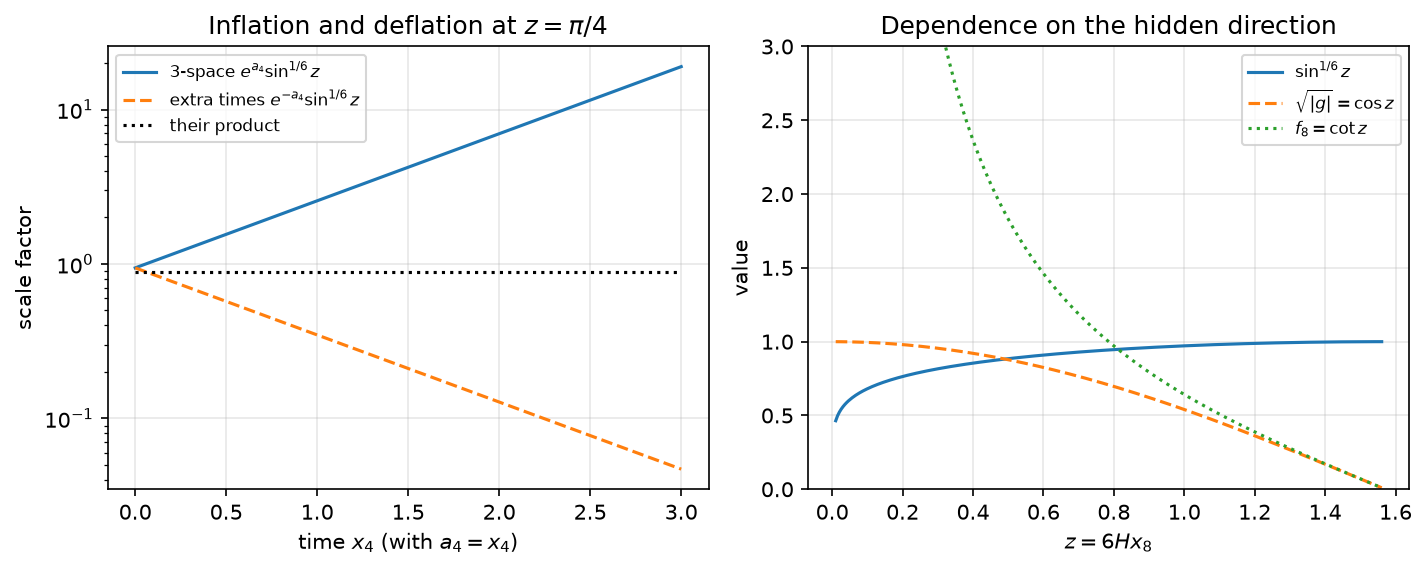

Figure 07b.1 saved as Revision/textbook/figures/07b_1_scale_factors.png


In [6]:
times = np.linspace(0.0, 3.0, 301)  # x4 from 0 to 3 (H = 1, A = 1: a4 = x4)
warp = np.sin(np.pi / 4) ** (1 / 6)  # sin^(1/6) z at z = pi/4
angles = np.linspace(0.01, np.pi / 2 - 0.01, 300)  # z inside (0, pi/2)
fig, (left, right) = plt.subplots(1, 2, figsize=(9.6, 3.9))
left.semilogy(times, np.exp(times) * warp, label="3-space $e^{a_4}\\sin^{1/6}z$")
left.semilogy(times, np.exp(-times) * warp, "--",
              label="extra times $e^{-a_4}\\sin^{1/6}z$")
left.semilogy(times, np.exp(times) * np.exp(-times) * warp**2, ":", color="black",
              label="their product")
left.set_xlabel("time $x_4$ (with $a_4 = x_4$)")
left.set_ylabel("scale factor")
left.set_title("Inflation and deflation at $z = \\pi/4$")
left.legend(fontsize=8)
right.plot(angles, np.sin(angles) ** (1 / 6), label="$\\sin^{1/6}z$")
right.plot(angles, np.cos(angles), "--", label="$\\sqrt{|g|} = \\cos z$")
right.plot(angles, 1 / np.tan(angles), ":", label="$f_8 = \\cot z$")
right.set_ylim(0, 3)
right.set_xlabel("$z = 6Hx_8$")
right.set_ylabel("value")
right.set_title("Dependence on the hidden direction")
right.legend(fontsize=8)
fig.tight_layout()
save_figure(fig, "scale_factors",
            "The author's metric along the deflating history $a_4 = AHx_4$ "
            "with the illustration values $A = 1$, $H = 1$ (a prescribed "
            "history, not a result). Left, at $z = \\pi/4$, against the time "
            "$x_4$ (logarithmic vertical axis, pure numbers): the scale factor "
            "of 3-space $e^{a_4}\\sin^{1/6}z$ grows, that of the three extra "
            "times $e^{-a_4}\\sin^{1/6}z$ shrinks exponentially, and their "
            "product stays constant. Right, at $x_4 = 0$, against $z = 6Hx_8$ "
            "from 0 to $\\pi/2$: the common warp $\\sin^{1/6}z$, the volume "
            "factor $\\sqrt{|g|} = \\cos z$ and the frame factor $\\cot z$ of the "
            "hidden direction.")

## 8. The Christoffel symbols

For a metric that is diagonal, the general formula $\Gamma^\lambda{}_{\mu\nu} =
\frac12 g^{\lambda\rho}(\partial_\mu g_{\rho\nu} + \partial_\nu g_{\rho\mu} -
\partial_\rho g_{\mu\nu})$ keeps only $\rho = \lambda$, because $g^{\lambda\rho} =
0$ otherwise; then $\partial_\mu g_{\lambda\nu}$ is nonzero only for $\nu =
\lambda$, $\partial_\nu g_{\lambda\mu}$ only for $\mu = \lambda$, and
$\partial_\lambda g_{\mu\nu}$ only for $\mu = \nu$. So

$$\Gamma^\lambda{}_{\mu\nu} = \frac{1}{2g_{\lambda\lambda}}\big(\delta_{\lambda\nu}
\partial_\mu g_{\lambda\lambda} + \delta_{\lambda\mu}\partial_\nu g_{\lambda\lambda}
- \delta_{\mu\nu}\partial_\lambda g_{\mu\mu}\big),$$

which the next cell evaluates for all $8^3$ index triples. It counts the
independent nonzero symbols ($\mu \le \nu$), compares all of them with the formula
record, and prints four of them in the ring: $\Gamma^{x_1}{}_{x_1x_4} = a_4'$ (3-space
stretches with time), $\Gamma^{x_5}{}_{x_4x_5} = -a_4'$ (the extra times shrink),
$\Gamma^{x_1}{}_{x_1x_8} = H\cot z$ and $\Gamma^{x_8}{}_{x_8x_8}$.

In [7]:
Gam = [[[sp.Integer(0)] * 8 for _ in range(8)] for _ in range(8)]  # Gam[l][mu][nu]
for l in range(8):
    for mu in range(8):
        for nu in range(8):
            value = 0
            if l == nu:
                value += cd(g[l], mu)
            if l == mu:
                value += cd(g[l], nu)
            if mu == nu:
                value -= cd(g[mu], l)
            if value != 0:
                Gam[l][mu][nu] = sp.expand(value / (2 * g[l]))
nonzero = [(l, mu, nu) for l in range(8) for mu in range(8) for nu in range(mu, 8)
           if not is_zero(Gam[l][mu][nu])]
report("independent nonzero Christoffel symbols", len(nonzero))
for l, mu, nu in [(0, 0, 3), (4, 3, 4), (0, 0, 7), (7, 7, 7)]:
    say(f"Gamma^{NAMES[l]}_{NAMES[mu]}{NAMES[nu]} = {sp.factor(Gam[l][mu][nu])}")
recorded = int(re.search(r"(\d+) independent nonzero",
                         revision_check(PYREP, "christoffel_symmetric_metric_"
                                        "compatible")["detail"]).group(1))
check(len(nonzero) == recorded == 25, "25 independent nonzero Christoffel symbols",
      record=reproduces(PYREP, "christoffel_symmetric_metric_compatible"))
listed = from_wolfram(record["christoffel_nonzero"])
check(len(listed) == 25 and all(is_zero(to_ring(v) - Gam[l - 1][mu - 1][nu - 1])
                                for l, mu, nu, v in listed),
      "every Christoffel symbol equals the formula record",
      record=f"{FORMULAS}, formula christoffel_nonzero")

RESULT independent nonzero Christoffel symbols = 25
Gamma^x1_x1x4 = A1
Gamma^x5_x4x5 = -A1
Gamma^x1_x1x8 = H*c/s**6
Gamma^x8_x8x8 = -6*H*(c**2 + s**12)/(c*s**6)
PASS 25 independent nonzero Christoffel symbols
     reproduces Revision/theory/reports/python-field-theory.json, check
    christoffel_symmetric_metric_compatible
PASS every Christoffel symbol equals the formula record
     reproduces Revision/theory/field-theory.json, formula christoffel_nonzero


## 9. The canonical spin connection

The canonical spin connection is fixed by the **vielbein postulate**
$\partial_\mu e^a{}_\nu - \Gamma^\lambda{}_{\mu\nu}e^a{}_\lambda +
\omega_\mu{}^a{}_b\,e^b{}_\nu = 0$ (the frame is carried along consistently with
the metric). Its solution is $\omega_\mu{}^a{}_b = e^a{}_\nu(\partial_\mu
e_b{}^\nu + \Gamma^\nu{}_{\mu\lambda}e_b{}^\lambda)$ with the inverse frame
$e_b{}^\nu = \delta_b^\nu/f_b$; for our diagonal frame this is

$$\omega_\mu{}^a{}_b = f_a\Big(\delta_{ab}\,\partial_\mu\frac{1}{f_b} +
\frac{\Gamma^a{}_{\mu b}}{f_b}\Big),\qquad \omega_{\mu ab} =
\eta_{aa}\,\omega_\mu{}^a{}_b .$$

The next cell computes it, checks that $\omega_{\mu ab} = -\omega_{\mu ba}$ and that
the vielbein postulate holds in all 512 components, counts the nonzero components
with $a < b$ (there should be 12), compares them with the formula record and prints
them.

In [8]:
om = [[[sp.Integer(0)] * 8 for _ in range(8)] for _ in range(8)]  # om[mu][a][b]
for mu in range(8):
    for a in range(8):
        for b in range(8):
            mixed = f[a] * ((cd(1 / f[b], mu) if a == b else 0) + Gam[a][mu][b] / f[b])
            om[mu][a][b] = sp.expand(ETA[a] * mixed)  # lowered with eta_aa
antisymmetric = all(is_zero(om[mu][a][b] + om[mu][b][a])
                    for mu in range(8) for a in range(8) for b in range(8))
postulate = all(is_zero((cd(f[a], mu) if a == nu else 0) - Gam[a][mu][nu] * f[a]
                        + ETA[a] * om[mu][a][nu] * f[nu])
                for mu in range(8) for a in range(8) for nu in range(8))
check(antisymmetric and postulate, "omega_mu ab = -omega_mu ba and the vielbein "
      "postulate holds in all 512 components",
      record=reproduces(PYREP, "vielbein_postulate"))
pairs = [(mu, a, b) for mu in range(8) for a in range(8) for b in range(a + 1, 8)
         if not is_zero(om[mu][a][b])]
for mu, a, b in pairs:
    say(f"omega_{NAMES[mu]} ({NAMES[a]})({NAMES[b]}) = {sp.factor(om[mu][a][b])}")
listed = from_wolfram(record["omega_nonzero"])
check(len(pairs) == 12 and len(listed) == 12 and all(
    is_zero(to_ring(v) - om[mu - 1][a - 1][b - 1]) for mu, a, b, v in listed),
      "exactly 12 nonzero components, equal to the formula record",
      record=reproduces(WLREP, "omega_components"))

PASS omega_mu ab = -omega_mu ba and the vielbein postulate holds in all 512 components
     reproduces Revision/theory/reports/python-field-theory.json, check
    vielbein_postulate
omega_x1 (x1)(x4) = A1*E*s
omega_x1 (x1)(x8) = E*H*s
omega_x2 (x2)(x4) = A1*E*s
omega_x2 (x2)(x8) = E*H*s
omega_x3 (x3)(x4) = A1*E*s
omega_x3 (x3)(x8) = E*H*s
omega_x5 (x4)(x5) = -A1*s/E
omega_x5 (x5)(x8) = -H*s/E
omega_x6 (x4)(x6) = -A1*s/E
omega_x6 (x6)(x8) = -H*s/E
omega_x7 (x4)(x7) = -A1*s/E
omega_x7 (x7)(x8) = -H*s/E
PASS exactly 12 nonzero components, equal to the formula record
     reproduces Revision/theory/reports/wolfram-field-theory.json, check omega_components


Each of the 12 components printed above is either $a_4'$ or $H$ times a factor
$\pm E^{\pm1}s$ that never vanishes: the connection vanishes only if $a_4' = 0$ AND
$H = 0$, and $H = 0$ is not a member of the author's family.

## 10. The spinor connection and the term $\gamma^\mu\Omega_\mu$

The spinor connection is $\Omega_\mu = \frac12\omega_{\mu ab}S^{ab} =
\sum_{a<b}\omega_{\mu ab}S^{ab}$ (the two halves of the double sum are equal
because both $\omega_{\mu ab}$ and $S^{ab}$ change sign when $a$ and $b$ are
exchanged). The coordinate gammas are $\gamma^\mu = \gamma^{(\mu)}/f_\mu$. The next
cell computes, for every direction $\mu$ separately (no sum), the matrix
$\gamma^\mu\Omega_\mu$ and writes it as $\alpha_\mu\gamma^{(x_4)} +
\beta_\mu\gamma^{(x_8)}$. The two numbers are found with traces, because
$\mathrm{tr}(\gamma^{(x_4)}\gamma^{(x_4)}) = -16$, $\mathrm{tr}(\gamma^{(x_8)}
\gamma^{(x_8)}) = 16$ and $\mathrm{tr}(\gamma^{(x_4)}\gamma^{(x_8)}) = 0$; the cell
checks that nothing else is left over. The hand calculation for an inflating
direction $i$, line by line:

$$\gamma^{x_i}\Omega_{x_i} = \frac{\gamma^{(i)}}{Es}\cdot\frac{Es}{2}\big(A_1
\gamma^{(i)}\gamma^{(x_4)} + H\gamma^{(i)}\gamma^{(x_8)}\big) = \frac12\big(A_1
\gamma^{(x_4)} + H\gamma^{(x_8)}\big),$$

where the factors $Es$ cancel and $(\gamma^{(i)})^2 = +1$. For a deflating extra
time $t$ the frame factor is $s/E$, $\Omega_{x_t} = -\frac{s}{2E}(A_1\gamma^{(x_4)}
\gamma^{(t)} + H\gamma^{(t)}\gamma^{(x_8)})$, and with $(\gamma^{(t)})^2 = -1$ and
$\gamma^{(t)}\gamma^{(x_4)}\gamma^{(t)} = +\gamma^{(x_4)}$ one gets
$\gamma^{x_t}\Omega_{x_t} = \frac12(-A_1\gamma^{(x_4)} + H\gamma^{(x_8)})$.

In [9]:
Om = []  # Omega_mu, mu = x1 .. x8
for mu in range(8):
    M = sp.zeros(16, 16)
    for a in range(8):
        for b in range(a + 1, 8):
            if om[mu][a][b] != 0:
                M += om[mu][a][b] * SAB[a][b]
    Om.append(M.applyfunc(sp.expand))
gam = [G[a] / f[a] for a in range(8)]  # the coordinate gammas gamma^mu
alpha, beta, rest_zero = [], [], True
for mu in range(8):
    M = (gam[mu] * Om[mu]).applyfunc(sp.expand)  # gamma^mu Omega_mu, no sum
    alpha.append(sp.expand(-(M * G[X4]).trace() / 16))  # coefficient of gamma^(x4)
    beta.append(sp.expand((M * G[X8]).trace() / 16))  # coefficient of gamma^(x8)
    rest_zero = rest_zero and all(
        is_zero(v) for v in (M - alpha[-1] * G[X4] - beta[-1] * G[X8]))
for mu in range(8):
    say(f"gamma^{NAMES[mu]} Omega_{NAMES[mu]} = ({alpha[mu]}) gamma^(x4) + "
        f"({beta[mu]}) gamma^(x8)")
listed = from_wolfram(record["gammaOmega_per_direction"])
check(rest_zero and all(is_zero(to_ring(al) - alpha[mu - 1])
                        and is_zero(to_ring(be) - beta[mu - 1])
                        for mu, al, be in listed),
      "per direction gamma^mu Omega_mu = alpha gamma^(x4) + beta gamma^(x8), equal "
      "to the formula record", record=f"{FORMULAS}, formula gammaOmega_per_direction")
total = sum((gam[mu] * Om[mu] for mu in range(8)), Z16)
check(all(is_zero(v) for v in (total - 3 * H * G[X8])),
      "gamma^mu Omega_mu = 3 H gamma^(x8) (summed over mu)",
      record=reproduces(PYREP, "gamma_mu_Omega_mu_equals_3H_gamma_x8"))
check(sp.expand(sum(alpha[0:3])) == sp.Rational(3, 2) * A1
      and sp.expand(sum(alpha[4:7])) == -sp.Rational(3, 2) * A1
      and sp.expand(sum(beta)) == 3 * H,
      "the x4 terms cancel (+3 A1/2 inflating, -3 A1/2 deflating), the six x8 "
      "terms add to 3 H",
      record=reproduces(PYREP, "time_terms_cancel_hidden_term_survives"))

gamma^x1 Omega_x1 = (A1/2) gamma^(x4) + (H/2) gamma^(x8)
gamma^x2 Omega_x2 = (A1/2) gamma^(x4) + (H/2) gamma^(x8)
gamma^x3 Omega_x3 = (A1/2) gamma^(x4) + (H/2) gamma^(x8)
gamma^x4 Omega_x4 = (0) gamma^(x4) + (0) gamma^(x8)
gamma^x5 Omega_x5 = (-A1/2) gamma^(x4) + (H/2) gamma^(x8)
gamma^x6 Omega_x6 = (-A1/2) gamma^(x4) + (H/2) gamma^(x8)
gamma^x7 Omega_x7 = (-A1/2) gamma^(x4) + (H/2) gamma^(x8)
gamma^x8 Omega_x8 = (0) gamma^(x4) + (0) gamma^(x8)
PASS per direction gamma^mu Omega_mu = alpha gamma^(x4) + beta gamma^(x8), equal to the
    formula record
     reproduces Revision/theory/field-theory.json, formula gammaOmega_per_direction
PASS gamma^mu Omega_mu = 3 H gamma^(x8) (summed over mu)
     reproduces Revision/theory/reports/python-field-theory.json, check
    gamma_mu_Omega_mu_equals_3H_gamma_x8
PASS the x4 terms cancel (+3 A1/2 inflating, -3 A1/2 deflating), the six x8 terms add to
    3 H
     reproduces Revision/theory/reports/python-field-theory.json, check
    time_terms_cancel

Figure 2 shows the cancellation: the coefficient of $\gamma^{(x_4)}$ (in units of
$a_4'$) is $+\frac12$ for each inflating direction and $-\frac12$ for each deflating
extra time, so its running sum climbs to $\frac32$ and falls back to 0; the
coefficient of $\gamma^{(x_8)}$ (in units of $H$) is $+\frac12$ for all six and adds
up to 3. The deflation of the extra times is exactly what cancels the time term of
the inflation.

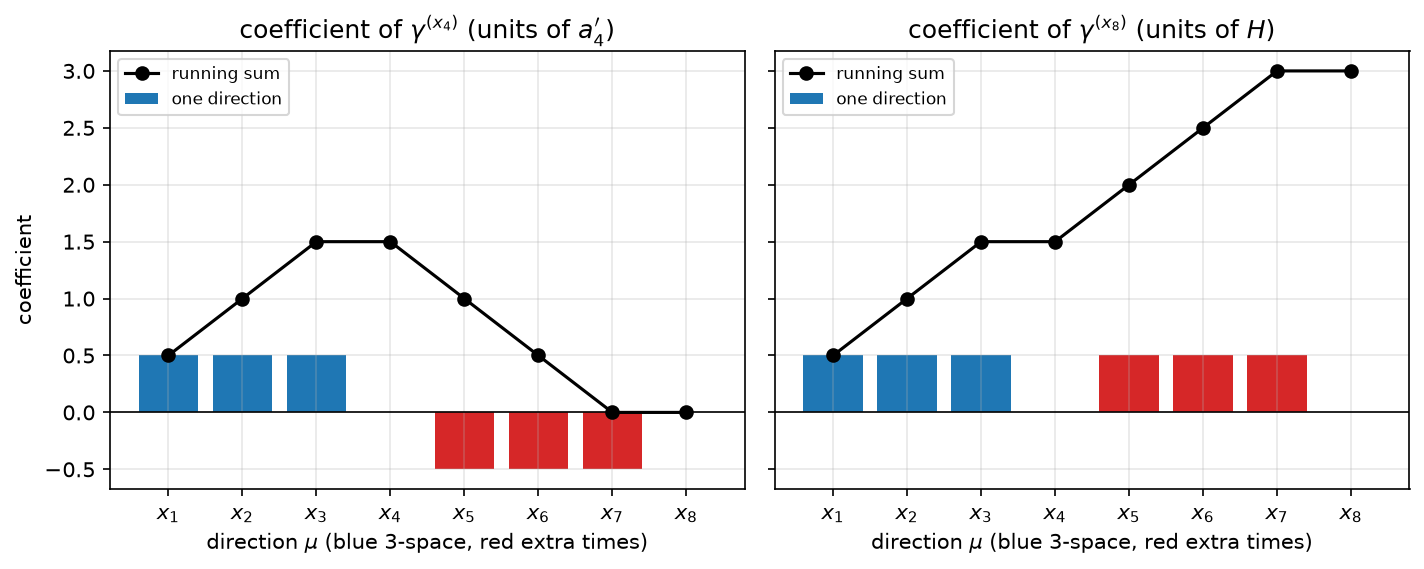

Figure 07b.2 saved as Revision/textbook/figures/07b_2_gamma_omega_per_direction.png


In [10]:
a_units = [float(sp.expand(v / A1)) if v != 0 else 0.0 for v in alpha]  # a4' units
b_units = [float(sp.expand(v / H)) if v != 0 else 0.0 for v in beta]  # H units
positions = np.arange(8)
fig, (left, right) = plt.subplots(1, 2, figsize=(9.6, 3.9), sharey=True)
for ax, values, unit, title in [
        (left, a_units, "$a_4'$", "coefficient of $\\gamma^{(x_4)}$"),
        (right, b_units, "$H$", "coefficient of $\\gamma^{(x_8)}$")]:
    ax.bar(positions, values, color=["tab:blue"] * 3 + ["grey"] + ["tab:red"] * 3
           + ["grey"], label="one direction")
    ax.plot(positions, np.cumsum(values), "ko-", label="running sum")
    ax.axhline(0.0, color="black", linewidth=0.8)
    ax.set_xticks(positions, [f"$x_{k}$" for k in range(1, 9)])
    ax.set_xlabel("direction $\\mu$ (blue 3-space, red extra times)")
    ax.set_title(f"{title} (units of {unit})")
    ax.legend(fontsize=8, loc="upper left")
left.set_ylabel("coefficient")
fig.tight_layout()
save_figure(fig, "gamma_omega_per_direction",
            "The spin-connection term $\\gamma^\\mu\\Omega_\\mu$ of the field "
            "equation, direction by direction (horizontal axis $\\mu = x_1$ to "
            "$x_8$; blue: inflating 3-space, red: deflating extra times, grey: "
            "$x_4$ and $x_8$, which give 0). Left: the coefficient of "
            "$\\gamma^{(x_4)}$ in units of $a_4'$; it is $+1/2$ for each "
            "inflating and $-1/2$ for each deflating direction, so the running "
            "sum (black) returns to 0. Right: the coefficient of $\\gamma^{(x_8)}$ "
            "in units of $H$; all six are $+1/2$ and the sum is 3. Hence "
            "$\\gamma^\\mu\\Omega_\\mu = 3H\\gamma^{(x_8)}$ for every $a_4$.")

## 11. Why the connection drops out of $L$ but not out of the field equation

$\Omega_\mu$ contains only generators $S^{(\mu)b}$ that share the index $\mu$ with
$\gamma^{(\mu)}$, and $\gamma^{(\mu)}$ anticommutes with such an $S^{(\mu)b}$. So
$\{\gamma^\mu, \Omega_\mu\} = 0$ for each $\mu$ separately. The connection enters
the symmetrised kinetic term only as $\frac12\bar\Psi\{\gamma^\mu,\Omega_\mu\}\Psi$
(the $\Omega$ parts of the two halves of $K$), so it drops out of $L$ in this
metric. It comes back through the variation: the derivative of $\sqrt{|g|}
\gamma^\mu$ appears when the action is varied (section 15), and

$$\frac{1}{2\sqrt{|g|}}\,\partial_\mu\big(\sqrt{|g|}\,\gamma^\mu\big)
= \frac{1}{2c}\,\partial_8\Big(c\,\frac{s^6}{c}\Big)\gamma^{(x_8)}
= \frac{6Hs^6\cdot c/s^6}{2c}\,\gamma^{(x_8)} = 3H\gamma^{(x_8)} .$$

The first equality: only $\mu = x_8$ contributes, because $\sqrt{|g|}\gamma^{x_4}
= c\,\gamma^{(x_4)}$ does not depend on $x_4$ and nothing depends on the other six
coordinates; $\gamma^{x_8} = \gamma^{(x_8)}/f_8 = (s^6/c)\gamma^{(x_8)}$. The
second: $c\cdot s^6/c = s^6 = \sin z$ and $\partial_8\sin z = 6H\cos z$. The third
cancels. This equals $\gamma^\mu\Omega_\mu$: the surviving term is the half-density
(volume and frame divergence) term. The next cell checks both statements.

In [11]:
anti = all(all(is_zero(v) for v in (gam[mu] * Om[mu] + Om[mu] * gam[mu]))
           for mu in range(8))
check(anti, "{gamma^mu, Omega_mu} = 0 for each mu: the connection drops out of L",
      record=reproduces(PYREP, "anticommutator_gamma_Omega_vanishes"))
divergence = sum((((sqrt_g * gam[mu]).applyfunc(lambda v: cd(v, mu)))
                  for mu in range(8)), Z16) / (2 * sqrt_g)
check(all(is_zero(v) for v in (divergence - 3 * H * G[X8])),
      "(1/(2 sqrt|g|)) d_mu (sqrt|g| gamma^mu) = 3 H gamma^(x8)",
      record=reproduces(PYREP, "divergence_of_sqrtg_gamma"))

PASS {gamma^mu, Omega_mu} = 0 for each mu: the connection drops out of L
     reproduces Revision/theory/reports/python-field-theory.json, check
    anticommutator_gamma_Omega_vanishes
PASS (1/(2 sqrt|g|)) d_mu (sqrt|g| gamma^mu) = 3 H gamma^(x8)
     reproduces Revision/theory/reports/python-field-theory.json, check
    divergence_of_sqrtg_gamma


## 12. Fields at one point: a jet algebra for both statistics

To vary the Lagrangian we need the field components and their derivatives at one
point as symbols. A **generator** is a triple `(kind, A, derivatives)`: `kind` 0
for a component $\chi_A = \Psi_A^*$ of $\Psi^\dagger$, `kind` 1 for a component
$\psi_A = \Psi_A$ of $\Psi$; `A` = 0 to 15; `derivatives` a sorted tuple of
coordinate positions (empty for the value itself, `(3,)` for $\partial_4$). An
element is a dictionary from sorted tuples of generators (monomials) to ring
coefficients, as in Notebook 07a, with one switch: `odd = True` makes the
generators anticommute (dirac16complex), `odd = False` makes them commute
(dirac16complex00).

- Products sort the generators; for odd generators every exchange gives $-1$ and a
  repeated generator gives 0; for even ones nothing changes sign.
- The conjugation reverses each product, exchanges $\chi_A \leftrightarrow \psi_A$
  (keeping the derivatives) and replaces $i$ by $-i$.
- The left (right) derivative with respect to a generator moves it to the far left
  (right) with the Grassmann signs; for commuting generators both are the ordinary
  partial derivative ($x^n \to n x^{n-1}$).
- The total derivative $d/dx_\mu$ differentiates the coefficient with `cd` and
  raises the derivative tuple of each generator in turn (product rule).

The next cell defines the class `Jet` and the vector helpers.

In [12]:
CHI, PSI = 0, 1  # the two kinds: components of Psi^dagger and of Psi


def gen(kind, A, derivatives=()):
    """The generator: component A of chi (kind 0) or psi (kind 1), differentiated
    along the coordinate positions in derivatives."""
    return (kind, A, tuple(sorted(derivatives)))


def sort_sign(keys, odd):
    """Sorted tuple of generators and the sign; (None, 0) for a zero product."""
    items, sign = list(keys), 1
    for end in range(len(items) - 1, 0, -1):  # bubble sort, counting exchanges
        for i in range(end):
            if items[i] > items[i + 1]:
                items[i], items[i + 1] = items[i + 1], items[i]
                sign = -sign
    if not odd:
        return tuple(items), 1  # commuting generators: no signs, squares allowed
    if any(items[i] == items[i + 1] for i in range(len(items) - 1)):
        return None, 0  # a repeated Grassmann generator: the product is zero
    return tuple(items), sign


class Jet:
    """An element of the jet algebra: self.terms maps monomials to coefficients."""

    def __init__(self, odd, terms=None):
        self.odd, self.terms = odd, {}
        for monomial, coefficient in (terms or {}).items():
            self.add(monomial, coefficient)

    def add(self, monomial, coefficient):
        total = sp.expand(self.terms.get(monomial, 0) + coefficient)
        if total == 0:
            self.terms.pop(monomial, None)
        else:
            self.terms[monomial] = total

    def __add__(self, other):
        result = Jet(self.odd, self.terms)
        for monomial, coefficient in other.terms.items():
            result.add(monomial, coefficient)
        return result

    def __sub__(self, other):
        return self + other.times(-1)

    def times(self, factor):  # an ordinary (ring) factor
        return Jet(self.odd, {k: factor * v for k, v in self.terms.items()})

    def __mul__(self, other):
        result = Jet(self.odd)
        for k1, v1 in self.terms.items():
            for k2, v2 in other.terms.items():
                monomial, sign = sort_sign(k1 + k2, self.odd)
                if monomial is not None:
                    result.add(monomial, sign * v1 * v2)
        return result

    def conj(self):
        result = Jet(self.odd)
        for monomial, coefficient in self.terms.items():
            images = [(1 - kind, A, d) for kind, A, d in reversed(monomial)]
            ordered, sign = sort_sign(images, self.odd)
            if ordered is not None:
                result.add(ordered, sign * sp.sympify(coefficient).subs(sp.I, -sp.I))
        return result

    def lderiv(self, key):
        result = Jet(self.odd)
        for monomial, coefficient in self.terms.items():
            if key in monomial:
                p = monomial.index(key)
                factor = (-1) ** p if self.odd else monomial.count(key)
                result.add(monomial[:p] + monomial[p + 1:], factor * coefficient)
        return result

    def rderiv(self, key):
        if not self.odd:
            return self.lderiv(key)
        result = Jet(self.odd)
        for monomial, coefficient in self.terms.items():
            if key in monomial:
                p = monomial.index(key)
                factor = (-1) ** (len(monomial) - 1 - p)
                result.add(monomial[:p] + monomial[p + 1:], factor * coefficient)
        return result

    def total(self, mu):
        result = Jet(self.odd)
        for monomial, coefficient in self.terms.items():
            derivative = cd(coefficient, mu)
            if derivative != 0:
                result.add(monomial, derivative)
            for p, (kind, A, d) in enumerate(monomial):
                raised = (kind, A, tuple(sorted(d + (mu,))))
                ordered, sign = sort_sign(monomial[:p] + (raised,) + monomial[p + 1:],
                                          self.odd)
                if ordered is not None:
                    result.add(ordered, sign * coefficient)
        return result

    def is_zero(self):
        return all(is_zero(v) for v in self.terms.values())


def column(odd, kind, derivatives=()):
    """The 16 generators of chi or psi (or of one of their derivatives)."""
    return [Jet(odd, {(gen(kind, A, derivatives),): 1}) for A in range(16)]


def matvec(M, v, odd):
    """The column M v."""
    out = [Jet(odd) for _ in range(16)]
    for i in range(16):
        for j in range(16):
            if M[i, j] != 0:
                out[i] = out[i] + v[j].times(M[i, j])
    return out


def vecmat(v, M, odd):
    """The row v M."""
    out = [Jet(odd) for _ in range(16)]
    for i in range(16):
        for j in range(16):
            if M[i, j] != 0:
                out[j] = out[j] + v[i].times(M[i, j])
    return out


def dot(row, col, odd):
    """The number row col (row first)."""
    result = Jet(odd)
    for x, y in zip(row, col):
        result = result + x * y
    return result


say("The jet algebra and the vector helpers are defined.")

The jet algebra and the vector helpers are defined.


## 13. The Lagrangian of both fields

The next cell builds, for each statistics, the jets $\psi = \Psi$, $\chi =
\Psi^\dagger$, the row $\bar\Psi = \chi C$, the covariant derivatives $D_\mu\psi =
\partial_\mu\psi + \Omega_\mu\psi$ and $D_\mu\bar\Psi = \partial_\mu\bar\Psi -
\bar\Psi\Omega_\mu$, the kinetic term $K = \frac12\sum_\mu(\bar\Psi\gamma^\mu
D_\mu\psi - D_\mu\bar\Psi\gamma^\mu\psi)$, $S = \bar\Psi\psi$, and

$$L = \sqrt{|g|}\,\big(K - mS - \tfrac{\lambda}{2}S^2\big).$$

It also builds the unsymmetrised form $L_u = \sqrt{|g|}(\bar\Psi\gamma^\mu
D_\mu\psi - mS - \frac{\lambda}{2}S^2)$ and the residual of the expected field
equation, $\mathcal{E} = \gamma^\mu D_\mu\psi - (m + \lambda S)\psi$, and counts
the monomials of $L$ by type: kinetic ($8 \times 32 = 256$: in each direction 16
terms $\chi\,\partial\psi$ and 16 terms $\partial\chi\,\psi$), mass (16, one for
each nonzero entry of $C$), and quartic. In the quartic term $S^2 = \sum_{A,B}
P_AP_B$ with the 16 pairs $P_A = \chi_A C_{A\pi(A)}\psi_{\pi(A)}$: for commuting
numbers the 16 squares $P_A^2$ and the $\binom{16}{2} = 120$ products of two
different pairs survive (136), for Grassmann numbers the squares vanish (120).

In [13]:
def build(odd, connection):
    """Lagrangian, unsymmetrised Lagrangian, field-equation residual and pieces
    for one statistics (odd True: Grassmann) and one spinor connection."""
    psi, chi = column(odd, PSI), column(odd, CHI)
    psibar = vecmat(chi, C, odd)  # Psibar = Psi^dagger C
    Dpsi = [[x + y for x, y in zip(column(odd, PSI, (mu,)),
                                   matvec(connection[mu], psi, odd))]
            for mu in range(8)]
    Dpsibar = [[x - y for x, y in zip(vecmat(column(odd, CHI, (mu,)), C, odd),
                                      vecmat(psibar, connection[mu], odd))]
               for mu in range(8)]
    K, Ku = Jet(odd), Jet(odd)
    for mu in range(8):
        forward = dot(psibar, matvec(gam[mu], Dpsi[mu], odd), odd)
        K = K + forward - dot(vecmat(Dpsibar[mu], gam[mu], odd), psi, odd)
        Ku = Ku + forward
    S = dot(psibar, psi, odd)
    potential = S.times(m) + (S * S).times(lam / 2)  # m S + (lambda/2) S^2
    L = (K.times(sp.Rational(1, 2)) - potential).times(sqrt_g)
    Lu = (Ku - potential).times(sqrt_g)
    dirac = [Jet(odd) for _ in range(16)]  # gamma^mu D_mu psi
    for mu in range(8):
        dirac = [x + y for x, y in zip(dirac, matvec(gam[mu], Dpsi[mu], odd))]
    V = Jet(odd, {(): m}) + S.times(lam)  # m + lambda S
    residual = [dirac[A] - V * psi[A] for A in range(16)]
    bar_residual = [Jet(odd)] * 16  # -(D_mu Psibar gamma^mu + V Psibar)
    for mu in range(8):
        bar_residual = [x - y for x, y in zip(bar_residual,
                                              vecmat(Dpsibar[mu], gam[mu], odd))]
    bar_residual = [x - V * y for x, y in zip(bar_residual, psibar)]
    return {"L": L, "Lu": Lu, "E": residual, "Ebar": bar_residual, "S": S,
            "psi": psi, "psibar": psibar, "dirac": dirac}


STATS = {"grassmann": True, "commuting": False}  # statistics -> odd
fields = {name: build(odd, Om) for name, odd in STATS.items()}
kinds = {}
for name, data in fields.items():
    monomials = data["L"].terms
    kinetic = sum(1 for k in monomials if any(d for (_, _, d) in k))
    quartic = sum(1 for k in monomials if len(k) == 4)
    kinds[name] = (kinetic, len(monomials) - kinetic - quartic, quartic)
    report(f"monomials of L, {name}", f"{len(monomials)} = {kinetic} kinetic + "
           f"{kinds[name][1]} mass + {quartic} quartic")

RESULT monomials of L, grassmann = 392 = 256 kinetic + 16 mass + 120 quartic
RESULT monomials of L, commuting = 408 = 256 kinetic + 16 mass + 136 quartic


The next cell compares the two counts with the numbers that the sympy verifier of
the Revision record wrote into the details of its reality checks, and draws them
by type (Figure 3).

PASS grassmann: L has 392 monomials, as recorded
     reproduces Revision/theory/reports/python-field-theory.json, check
    grassmann_lagrangian_real
PASS commuting: L has 408 monomials, as recorded
     reproduces Revision/theory/reports/python-field-theory.json, check
    commuting_lagrangian_real
PASS the difference is the 16 squares of the pairs in S^2 (136 - 120)


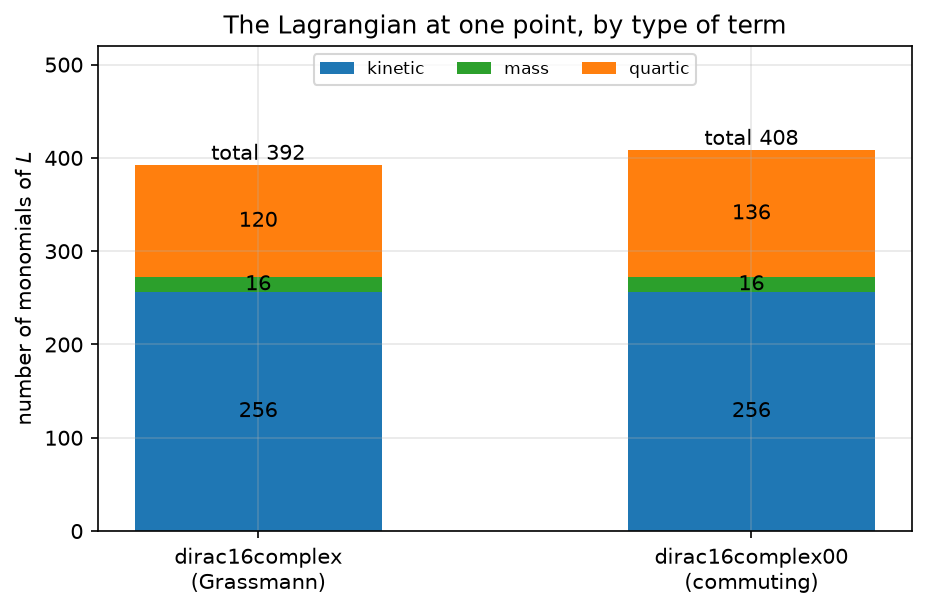

Figure 07b.3 saved as Revision/textbook/figures/07b_3_lagrangian_monomials.png


In [14]:
for name in STATS:
    detail = revision_check(PYREP, f"{name}_lagrangian_real")["detail"]
    recorded = int(re.search(r"\((\d+) monomials", detail).group(1))
    check(len(fields[name]["L"].terms) == recorded,
          f"{name}: L has {recorded} monomials, as recorded",
          record=reproduces(PYREP, f"{name}_lagrangian_real"))
check(kinds["grassmann"] == (256, 16, 120) and kinds["commuting"] == (256, 16, 136),
      "the difference is the 16 squares of the pairs in S^2 (136 - 120)")

fig, ax = plt.subplots(figsize=(7.0, 4.2))
labels = ["dirac16complex\n(Grassmann)", "dirac16complex00\n(commuting)"]
bottoms = np.zeros(2)
for index, (part, colour) in enumerate([("kinetic", "tab:blue"), ("mass", "tab:green"),
                                        ("quartic", "tab:orange")]):
    values = np.array([kinds["grassmann"][index], kinds["commuting"][index]])
    ax.bar(labels, values, bottom=bottoms, color=colour, label=part, width=0.5)
    for x, (value, bottom) in enumerate(zip(values, bottoms)):
        ax.text(x, bottom + value / 2, str(value), ha="center", va="center")
    bottoms = bottoms + values
for x, total in enumerate(bottoms):
    ax.text(x, total + 6, f"total {int(total)}", ha="center")
ax.set_ylim(0, 520)  # room above the bars for the legend
ax.set_ylabel("number of monomials of $L$")
ax.set_title("The Lagrangian at one point, by type of term")
ax.legend(loc="upper center", ncol=3, fontsize=8)
save_figure(fig, "lagrangian_monomials",
            "The number of monomials of the Lagrangian $L$ of the two fields in the "
            "author's metric, written in the jet algebra (the field components and "
            "their first derivatives at one point as generators), split into "
            "kinetic terms (256 for both), mass terms (16 for both) and quartic "
            "terms from $\\frac{\\lambda}{2}S^2$. The only difference between the "
            "two statistics: for commuting components the 16 squares of the pairs "
            "$\\bar\\Psi_A\\Psi_B$ survive (136 quartic terms), for anticommuting "
            "components they vanish (120); totals 408 and 392, the numbers of the "
            "Revision record.")

## 14. Reality, the total divergence, and the connection that drops out

Three exact statements, for both statistics:

1. $L^* = L$: the Lagrangian is real. The proof by hand uses that $C\gamma^{(a)}$
   is real and antisymmetric (so the two halves of $K$ are complex conjugates of
   each other) and that $C$ is real and symmetric (so $S^* = S$). The control: the
   unsymmetrised $L_u$ is NOT real, so the test is not empty.
2. $L = L_u - \frac12\partial_\mu\big(\sqrt{|g|}\,\bar\Psi\gamma^\mu\Psi\big)$:
   the two forms differ by a total divergence and give the same field equations.
3. In this metric $L$ computed with $\Omega_\mu$ equals $L$ computed with
   $\Omega_\mu$ set to zero (section 11).

The next cell checks all three and names the Revision checks that state them.

In [15]:
no_connection = [Z16] * 8  # Omega_mu = 0
for name, odd in STATS.items():
    data = fields[name]
    L, Lu = data["L"], data["Lu"]
    check((L.conj() - L).is_zero() and not (Lu.conj() - Lu).is_zero(),
          f"{name}: L is real, the unsymmetrised L_u is not",
          record=reproduces(PYREP, f"{name}_controls_not_vacuous"))
    current = Jet(odd)
    for mu in range(8):
        current = current + dot(data["psibar"], matvec(gam[mu], data["psi"], odd),
                                odd).times(sqrt_g).total(mu)
    check((L - Lu + current.times(sp.Rational(1, 2))).is_zero(),
          f"{name}: L = L_u - (1/2) d_mu (sqrt|g| Psibar gamma^mu Psi)",
          record=reproduces(PYREP, f"{name}_total_divergence_relation"))
    flat_connection = build(odd, no_connection)["L"]
    tag = "G" if odd else "C"
    check((L - flat_connection).is_zero(),
          f"{name}: L with Omega equals L with Omega = 0 in this metric",
          record=reproduces(WLREP, f"L_spin_connection_drops_out_{tag}"))

PASS grassmann: L is real, the unsymmetrised L_u is not
     reproduces Revision/theory/reports/python-field-theory.json, check
    grassmann_controls_not_vacuous
PASS grassmann: L = L_u - (1/2) d_mu (sqrt|g| Psibar gamma^mu Psi)
     reproduces Revision/theory/reports/python-field-theory.json, check
    grassmann_total_divergence_relation
PASS grassmann: L with Omega equals L with Omega = 0 in this metric
     reproduces Revision/theory/reports/wolfram-field-theory.json, check
    L_spin_connection_drops_out_G
PASS commuting: L is real, the unsymmetrised L_u is not
     reproduces Revision/theory/reports/python-field-theory.json, check
    commuting_controls_not_vacuous
PASS commuting: L = L_u - (1/2) d_mu (sqrt|g| Psibar gamma^mu Psi)
     reproduces Revision/theory/reports/python-field-theory.json, check
    commuting_total_divergence_relation
PASS commuting: L with Omega equals L with Omega = 0 in this metric
     reproduces Revision/theory/reports/wolfram-field-theory.json, check


## 15. The Euler-Lagrange equations

**The derivation by hand** (commuting field; the Grassmann case follows below).
Write $V = m + \lambda S$ and $L/\sqrt{|g|} = \frac12\Psi^\dagger C\gamma^\mu(
\partial_\mu\Psi + \Omega_\mu\Psi) - \frac12(\partial_\mu\Psi^\dagger C -
\Psi^\dagger C\Omega_\mu)\gamma^\mu\Psi - m\Psi^\dagger C\Psi -
\frac{\lambda}{2}(\Psi^\dagger C\Psi)^2$. Vary the component $\Psi_A^* = \chi_A$.

- Step 1. $\partial L/\partial\chi_A = \sqrt{|g|}\big[\frac12(C\gamma^\mu
  D_\mu\Psi)_A + \frac12(C\Omega_\mu\gamma^\mu\Psi)_A - V(C\Psi)_A\big]$ (every
  term with an undifferentiated $\chi$ contributes its column entry $A$; the chain
  rule gives $\partial(\frac{\lambda}{2}S^2)/\partial\chi_A = \lambda S(C\Psi)_A$).
- Step 2. $\partial L/\partial(\partial_\mu\chi_A) = -\frac12\sqrt{|g|}\,
  (C\gamma^\mu\Psi)_A$ (only the second term contains $\partial_\mu\chi$).
- Step 3. The Euler-Lagrange expression is Step 1 minus $\partial_\mu$ of Step 2,
  that is Step 1 plus $\frac12\partial_\mu(\sqrt{|g|}\,C\gamma^\mu\Psi)_A$.
- Step 4. By the product rule and section 11, $\partial_\mu(\sqrt{|g|}\gamma^\mu
  \Psi) = 2\sqrt{|g|}\gamma^\mu\Omega_\mu\Psi + \sqrt{|g|}\gamma^\mu\partial_\mu
  \Psi$, and $\gamma^\mu\Omega_\mu = -\Omega_\mu\gamma^\mu$ for each $\mu$.
- Step 5. Adding: the terms $\pm\frac12 C\Omega_\mu\gamma^\mu\Psi$ cancel, and
  $\frac12C\gamma^\mu D_\mu\Psi + \frac12 C\gamma^\mu\Omega_\mu\Psi + \frac12
  C\gamma^\mu\partial_\mu\Psi = C\gamma^\mu D_\mu\Psi$. So the expression is
  $\sqrt{|g|}\,\big(C(\gamma^\mu D_\mu\Psi - V\Psi)\big)_A$.
- Step 6. $\sqrt{|g|} = \cos z \ne 0$ and $C$ is invertible ($C^2 = 1$), so the
  16 expressions vanish exactly when $\gamma^\mu D_\mu\Psi = (m + \lambda S)\Psi$.

**Grassmann components.** The left derivative with respect to $\chi_A$ is used. In
every term of $L$ the factor $\chi$ (or $\partial_\mu\chi$) stands on the far left,
so moving it there costs no sign, and $S$ is even; Steps 1 to 6 go through word for
word. Varying $\psi_B$ with the right derivative gives the adjoint equation
$D_\mu\bar\Psi\gamma^\mu = -(m + \lambda S)\bar\Psi$, which is the Dirac conjugate
of the first one.

The next cell lets the computer do all of this: for every $A$ it computes
$\partial_L L/\partial\chi_A - \sum_\mu \frac{d}{dx_\mu}\partial_L L/\partial(
\partial_\mu\chi_A)$ and compares it with $\sqrt{|g|}(C\mathcal{E})_A$; as a control
it repeats the comparison with $m$ replaced by $-m$, which must fail.

In [16]:
def euler_lagrange_chi(L, A):
    """dL/dchi_A - d_mu dL/d(d_mu chi_A), left derivatives."""
    result = L.lderiv(gen(CHI, A))
    for mu in range(8):
        result = result - L.lderiv(gen(CHI, A, (mu,))).total(mu)
    return result


def euler_lagrange_psi(L, B):
    """dL/dpsi_B - d_mu dL/d(d_mu psi_B), right derivatives."""
    result = L.rderiv(gen(PSI, B))
    for mu in range(8):
        result = result - L.rderiv(gen(PSI, B, (mu,))).total(mu)
    return result


for name, odd in STATS.items():
    data = fields[name]
    L, residual, psi = data["L"], data["E"], data["psi"]
    expected = matvec(C, residual, odd)  # C times the residual
    ok = all((euler_lagrange_chi(L, A) - expected[A].times(sqrt_g)).is_zero()
             for A in range(16))
    wrong = matvec(C, [residual[B] + psi[B].times(2 * m) for B in range(16)], odd)
    control = not (euler_lagrange_chi(L, 0) - wrong[0].times(sqrt_g)).is_zero()
    check(ok and control, f"{name}: varying Psi^dagger gives gamma^mu D_mu Psi = "
          "(m + lambda S) Psi in all 16 components (control m -> -m fails)",
          record=reproduces(PYREP, f"{name}_euler_lagrange_psibar_variation"))
    ok = all((euler_lagrange_psi(L, B) - data["Ebar"][B].times(sqrt_g)).is_zero()
             for B in range(16))
    check(ok, f"{name}: varying Psi gives D_mu Psibar gamma^mu = -(m + lambda S) "
          "Psibar", record=reproduces(PYREP, f"{name}_euler_lagrange_psi_variation"))
    conjugate_row = vecmat([x.conj() for x in residual], C, odd)
    check(all((conjugate_row[B] - data["Ebar"][B]).is_zero() for B in range(16)),
          f"{name}: the adjoint equation is the Dirac conjugate of the field equation",
          record=reproduces(PYREP, f"{name}_adjoint_equation_is_conjugate"))

PASS grassmann: varying Psi^dagger gives gamma^mu D_mu Psi = (m + lambda S) Psi in all 16
    components (control m -> -m fails)
     reproduces Revision/theory/reports/python-field-theory.json, check
    grassmann_euler_lagrange_psibar_variation
PASS grassmann: varying Psi gives D_mu Psibar gamma^mu = -(m + lambda S) Psibar
     reproduces Revision/theory/reports/python-field-theory.json, check
    grassmann_euler_lagrange_psi_variation
PASS grassmann: the adjoint equation is the Dirac conjugate of the field equation
     reproduces Revision/theory/reports/python-field-theory.json, check
    grassmann_adjoint_equation_is_conjugate
PASS commuting: varying Psi^dagger gives gamma^mu D_mu Psi = (m + lambda S) Psi in all 16
    components (control m -> -m fails)
     reproduces Revision/theory/reports/python-field-theory.json, check
    commuting_euler_lagrange_psibar_variation
PASS commuting: varying Psi gives D_mu Psibar gamma^mu = -(m + lambda S) Psibar
     reproduces Revision/theory/r

## 16. The equations written out in the author's metric

Since $\gamma^\mu = \gamma^{(\mu)}/f_\mu$ and $\gamma^\mu\Omega_\mu = 3H
\gamma^{(x_8)}$, the Dirac operator is

$$\gamma^\mu D_\mu\Psi = \sum_{a=1}^{8}\frac{1}{f_a}\gamma^{(a)}\partial_a\Psi +
3H\gamma^{(x_8)}\Psi,\qquad \frac{1}{f_a} = \frac{1}{Es}\ (x_1, x_2, x_3),\ 1\
(x_4),\ \frac{E}{s}\ (x_5, x_6, x_7),\ \frac{s^6}{c} = \tan z\ (x_8).$$

The coefficient of the extra-time derivatives, $e^{a_4}\sin^{-1/6}z$, grows as the
extra times deflate. The next cell checks this form for both statistics, then
turns each of our 16 component equations into an ordinary sympy expression in the
symbols `d<a>_<B>` (for $\partial_a\Psi_B$) and `P<B>` (for $\Psi_B$), and compares
it with the corresponding equation of the formula record (key
`field_equation_components`, left-hand sides), term by term. It prints the first
equation in both forms.

In [17]:
for name, odd in STATS.items():
    data = fields[name]
    explicit = matvec(G[X8] * 3 * H, data["psi"], odd)  # 3 H gamma^(x8) psi
    for a in range(8):
        explicit = [x + y for x, y in zip(explicit, matvec(
            G[a] / f[a], column(odd, PSI, (a,)), odd))]
    tag = "G" if odd else "C"
    check(all((data["dirac"][A] - explicit[A]).is_zero() for A in range(16)),
          f"{name}: gamma^mu D_mu Psi = sum_a (1/f_a) gamma^(a) d_a Psi + 3 H "
          "gamma^(x8) Psi", record=reproduces(WLREP, f"Dirac_operator_explicit_{tag}"))


def as_sympy(element):
    """A linear jet element as a sympy expression in d<a>_<B> and P<B>."""
    total = 0
    for ((kind, B, d),), coefficient in element.terms.items():
        symbol = f"d{d[0] + 1}_{B + 1}" if d else f"P{B + 1}"
        total += coefficient * sp.Symbol(symbol)
    return total


ours = [as_sympy(x) for x in fields["grassmann"]["dirac"]]
theirs = [to_ring(from_wolfram(text.split("==")[0]))
          for text in record["field_equation_components"]]
say(f"equation 1, this notebook: {ours[0]} = V P1")
say(f"equation 1, formula record: {theirs[0]} = V P1")
check(len(theirs) == 16 and all(is_zero(x - y) for x, y in zip(ours, theirs)),
      "all 16 component equations equal the formula record term by term",
      record=f"{FORMULAS}, formula field_equation_components")

PASS grassmann: gamma^mu D_mu Psi = sum_a (1/f_a) gamma^(a) d_a Psi + 3 H gamma^(x8) Psi
     reproduces Revision/theory/reports/wolfram-field-theory.json, check
    Dirac_operator_explicit_G
PASS commuting: gamma^mu D_mu Psi = sum_a (1/f_a) gamma^(a) d_a Psi + 3 H gamma^(x8) Psi
     reproduces Revision/theory/reports/wolfram-field-theory.json, check
    Dirac_operator_explicit_C
equation 1, this notebook: E*d5_15/s + E*d6_16/s + E*d7_9/s + 3*H*P9 - d4_14 +
    d8_9*s**6/c - d1_16/(E*s) + d2_15/(E*s) - d3_14/(E*s) = V P1
equation 1, formula record: E*d5_15/s + E*d6_16/s + E*d7_9/s + 3*H*P9 - d4_14 +
    d8_9*s**6/c - d1_16/(E*s) + d2_15/(E*s) - d3_14/(E*s) = V P1
PASS all 16 component equations equal the formula record term by term
     reproduces Revision/theory/field-theory.json, formula field_equation_components


Figure 4 shows which components are coupled. Every frame gamma is a signed
permutation matrix, so each equation contains one derivative term per direction. A
square of the map (row $A$ = equation, column $B$ = component) is coloured by the
number of derivatives $\partial_a\Psi_B$ in equation $A$ and labelled with the
directions $a$. Each equation contains only four components, each with two
directions, and the equations of rows 1 to 8 (chirality $\Gamma = -1$) contain only
components 9 to 16 ($\Gamma = +1$) and back: every gamma is block off-diagonal in
the chiral split. The term $3H\gamma^{(x_8)}\Psi$ sits in the squares labelled
with 8, next to $\tan z\,\partial_8$ of the same component.

PASS each equation couples 4 components with 2 directions each, across the chiral halves


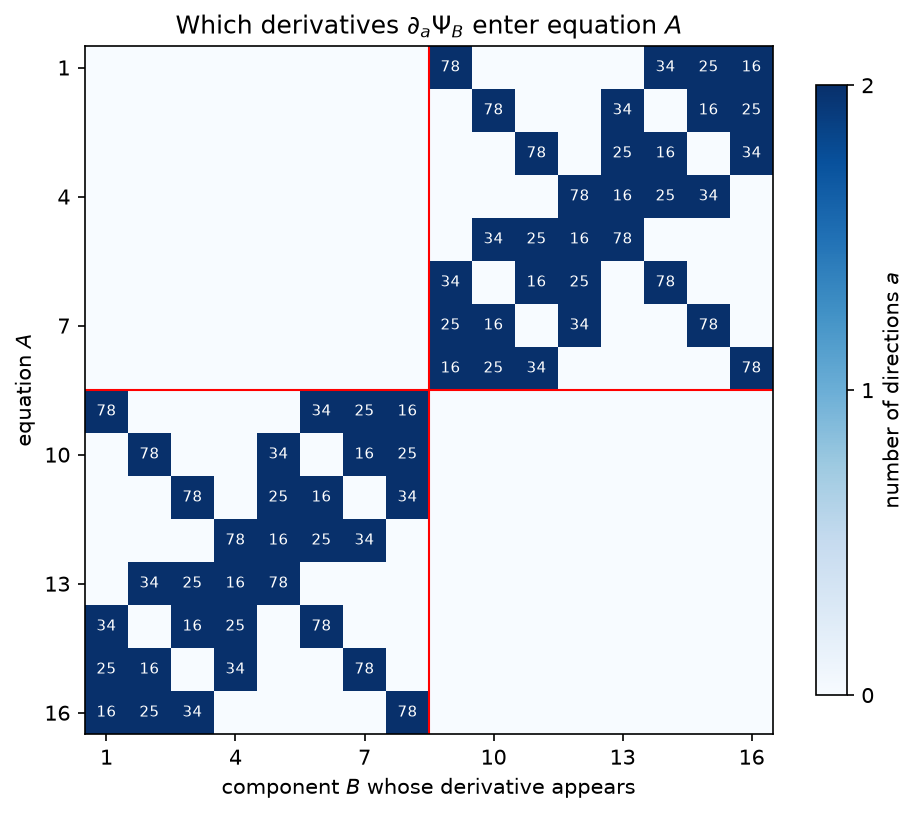

Figure 07b.4 saved as Revision/textbook/figures/07b_4_coupling_map.png


In [18]:
counts = np.zeros((16, 16), dtype=int)
tags = [["" for _ in range(16)] for _ in range(16)]
for a in range(8):
    for A in range(16):
        for B in range(16):
            if G[a][A, B] != 0:
                counts[A, B] += 1
                tags[A][B] += str(a + 1)
four_twos = all(np.count_nonzero(counts[A]) == 4 and counts[A].max() == 2
                for A in range(16))  # 4 components, each with 2 directions
check(four_twos and int(counts.sum()) == 128
      and not counts[:8, :8].any() and not counts[8:, 8:].any(),
      "each equation couples 4 components with 2 directions each, across the chiral "
      "halves")

fig, ax = plt.subplots(figsize=(7.4, 6.6))
image = ax.imshow(counts, cmap="Blues", vmin=0, vmax=2)
for A in range(16):
    for B in range(16):
        if tags[A][B]:
            ax.text(B, A, tags[A][B], ha="center", va="center", fontsize=7,
                    color="white" if counts[A, B] == 2 else "black")
ax.axhline(7.5, color="red", linewidth=1)
ax.axvline(7.5, color="red", linewidth=1)
ax.set_xticks(range(0, 16, 3), [str(k + 1) for k in range(0, 16, 3)])
ax.set_yticks(range(0, 16, 3), [str(k + 1) for k in range(0, 16, 3)])
ax.set_xlabel("component $B$ whose derivative appears")
ax.set_ylabel("equation $A$")
ax.set_title("Which derivatives $\\partial_a\\Psi_B$ enter equation $A$")
ax.grid(False)
fig.colorbar(image, ax=ax, ticks=[0, 1, 2], shrink=0.8,
             label="number of directions $a$")
save_figure(fig, "coupling_map",
            "The coupling map of the 16 component field equations in the author's "
            "metric: row $A$ is the equation $(\\gamma^\\mu D_\\mu\\Psi)_A = "
            "V\\Psi_A$, column $B$ a component; a square is coloured by the number "
            "of directions $a$ whose derivative $\\partial_a\\Psi_B$ appears in "
            "equation $A$, and the digits name those directions ($1$ to $8$ for "
            "$x_1$ to $x_8$). Every equation contains 4 components with 2 "
            "directions each. The red lines separate the chiral halves: rows 1 to 8 "
            "involve only components 9 to 16 and rows 9 to 16 only components 1 to "
            "8. The term $3H\\gamma^{(x_8)}\\Psi$ appears in the squares that "
            "contain the digit 8.")

## 17. The chiral blocks and the evolution form

Two more ways of writing the same 16 equations; both are stated in the Revision
formula record.

**The chiral blocks.** Split $\Psi$ into its upper half $\psi_-$ (components 1 to
8, where the chirality matrix $\Gamma = \mathrm{diag}(-I_8, I_8)$ is $-1$) and its
lower half $\psi_+$ (components 9 to 16, where $\Gamma = +1$). Every frame gamma
is block off-diagonal,

$$\gamma^{(a)} = \begin{pmatrix} 0 & \bar\tau_a \\ \tau_a & 0 \end{pmatrix},$$

with $8\times8$ blocks $\bar\tau_a$ (upper right) and $\tau_a$ (lower left), and
$\bar\tau_{x_8} = \tau_{x_8} = I_8$. Multiplying a block matrix by the column
$(\psi_-, \psi_+)$ gives $(\bar\tau_a\psi_+, \tau_a\psi_-)$: the upper rows see
only the lower half and the lower rows only the upper half. The mass term
$V\Psi$, $V = m + \lambda S$, keeps each half in its own rows. So the field
equation is the pair

$$\sum_a\frac{1}{f_a}\bar\tau_a\partial_a\psi_+ + 3H\bar\tau_{x_8}\psi_+ =
V\psi_-,\qquad \sum_a\frac{1}{f_a}\tau_a\partial_a\psi_- + 3H\tau_{x_8}\psi_- =
V\psi_+ .$$

The derivatives and the gravitational term of one half are balanced by the mass
term of the other half: the mass term and the gravitational term both couple the
two chiral halves (the coupling map of Figure 4 shows the same fact).

**The evolution form.** Write the explicit equation of section 16 with the $x_4$
term separately ($f_4 = 1$) and solve it for $\partial_4\Psi$, line by line:

$$\gamma^{(x_4)}\partial_4\Psi + \sum_{a\neq4}\frac{1}{f_a}\gamma^{(a)}
\partial_a\Psi + 3H\gamma^{(x_8)}\Psi = V\Psi$$
$$\gamma^{(x_4)}\partial_4\Psi = V\Psi - \sum_{a\neq4}\frac{1}{f_a}\gamma^{(a)}
\partial_a\Psi - 3H\gamma^{(x_8)}\Psi$$
$$\partial_4\Psi = -\gamma^{(x_4)}\Big[V\Psi - \sum_{a\neq4}\frac{1}{f_a}
\gamma^{(a)}\partial_a\Psi - 3H\gamma^{(x_8)}\Psi\Big] .$$

The second line moves every other term to the right side; the third multiplies
from the left by $-\gamma^{(x_4)}$ and uses $-\gamma^{(x_4)}\gamma^{(x_4)} = 1$
(because $(\gamma^{(x_4)})^2 = -1$). So the time derivative of every component
is fixed by the field and its derivatives along the other seven directions at the
same time $x_4$: the slices $x_4 = $ const are **non-characteristic** (the
coefficient $\gamma^{(x_4)}$ of $\partial_4$ is invertible; $g^{44} = -1 \neq 0$).
Scope, from the Revision scope record: this does NOT make the initial-value
problem well posed. For data that depend on the extra times the growth rates of
the modes have no upper bound (check extra_time_growth_rates_unbounded of
Revision/theory/reports/python-scope.json).

The next cell reads the blocks from the formula record and compares them with the
gammas, checks $\Gamma = \mathrm{diag}(-I_8, I_8)$, and verifies the evolution form
exactly for both statistics: with $R$ the right side of the third line,
$\gamma^{(x_4)}(\partial_4\Psi - R)$ must equal the field-equation residual
$\mathcal{E} = \gamma^\mu D_\mu\Psi - (m + \lambda S)\Psi$ in all 16 components.

In [19]:
blocks = {}  # direction name -> (tau-bar_a, tau_a)
for text in record["field_equation_blocks"]:
    # the Wolfram list {"x1", {{...}}, {{...}}} is the JSON list ["x1", [[...]], [[...]]]
    name, upper, lower = json.loads(text.replace("{", "[").replace("}", "]"))
    blocks[name] = (sp.Matrix(upper), sp.Matrix(lower))
GAMMA = sp.Matrix(fixture["Gamma"])  # the chirality matrix of Revision/algebra
Z8 = sp.zeros(8, 8)
blocks_ok = sorted(blocks) == NAMES and GAMMA == sp.diag(*([-1] * 8 + [1] * 8))
for a in range(8):
    upper, lower = blocks[NAMES[a]]
    blocks_ok = (blocks_ok and G[a][:8, :8] == Z8 and G[a][8:, 8:] == Z8  # zero
                 and G[a][:8, 8:] == upper and G[a][8:, :8] == lower)  # the blocks
blocks_ok = blocks_ok and blocks["x8"][0] == sp.eye(8) and blocks["x8"][1] == sp.eye(8)
check(blocks_ok, "Gamma = diag(-I8, I8); every gamma^(a) is block off-diagonal with the "
      "blocks of the formula record; tau-bar_x8 = tau_x8 = I8",
      record=reproduces(WLREP, "block_form"))

for name, odd in STATS.items():
    data = fields[name]
    psi = data["psi"]
    V = Jet(odd, {(): m}) + data["S"].times(lam)  # m + lambda S
    others = matvec(3 * H * G[X8], psi, odd)  # 3 H gamma^(x8) Psi, then the sum
    for a in range(8):
        if a != X4:  # (1/f_a) gamma^(a) d_a Psi for the seven other directions
            others = [x + y for x, y in zip(others, matvec(
                G[a] / f[a], column(odd, PSI, (a,)), odd))]
    bracket = [V * psi[A] - others[A] for A in range(16)]  # the square bracket
    right = matvec(-G[X4], bracket, odd)  # R = -gamma^(x4) [ ... ]
    difference = [x - y for x, y in zip(column(odd, PSI, (X4,)), right)]  # d4 Psi - R
    left = matvec(G[X4], difference, odd)  # gamma^(x4) (d4 Psi - R)
    tag = "G" if odd else "C"
    check(all((left[A] - data["E"][A]).is_zero() for A in range(16)),
          f"{name}: the evolution form d4 Psi = R is the field equation "
          "(gamma^(x4) (d4 Psi - R) = E in all 16 components)",
          record=reproduces(WLREP, f"evolution_form_{tag}"))

PASS Gamma = diag(-I8, I8); every gamma^(a) is block off-diagonal with the blocks of the
    formula record; tau-bar_x8 = tau_x8 = I8
     reproduces Revision/theory/reports/wolfram-field-theory.json, check block_form
PASS grassmann: the evolution form d4 Psi = R is the field equation (gamma^(x4) (d4 Psi -
    R) = E in all 16 components)
     reproduces Revision/theory/reports/wolfram-field-theory.json, check evolution_form_G
PASS commuting: the evolution form d4 Psi = R is the field equation (gamma^(x4) (d4 Psi -
    R) = E in all 16 components)
     reproduces Revision/theory/reports/wolfram-field-theory.json, check evolution_form_C


## 18. Non-triviality: the gravitational term in the field equation

The difference between the field-equation residual computed with the canonical
spin connection and the one computed with $\Omega_\mu = 0$ is $\gamma^\mu\Omega_\mu
\Psi = 3H\gamma^{(x_8)}\Psi$. Because $\gamma^{(x_8)}$ is a signed permutation
matrix with $(\gamma^{(x_8)})^2 = 1$, this vanishes only for $\Psi = 0$ when $H > 0$.
So in the diagonal frame and in the variables $\Psi$ the Euler-Lagrange equations
of both fields always contain a gravitational term through the spin connection (the
Revision record's non-triviality tests [1] and [2]). Its exact scope, stated in the
Revision record: the value $3H\gamma^{(x_8)}$ belongs to this frame and these
variables (it vanishes in a frame boosted in the $(x_4, x_8)$ plane, and the
rescaling $\Psi = \sin^{-1/2}z\,\chi$ removes it), while the frame-independent
facts are that $\Omega_\mu$ itself vanishes in no frame (the metric is curved for
$H > 0$) and that the frame factors $1/f_a$ enter every derivative term. The next
cell checks the difference for both statistics.

In [20]:
for name, odd in STATS.items():
    data = fields[name]
    without = build(odd, no_connection)["E"]  # residual with Omega = 0
    gravity = matvec(3 * H * G[X8], data["psi"], odd)
    ok = all((data["E"][A] - without[A] - gravity[A]).is_zero() for A in range(16))
    nonzero = all(len(gravity[A].terms) == 1 for A in range(16))
    number = "1_dirac16complex" if odd else "2_dirac16complex00"
    check(ok and nonzero, f"{name}: residual(Omega) - residual(Omega = 0) = 3 H "
          "gamma^(x8) Psi, nonzero in all 16 components",
          record=reproduces(WLREP, f"nontriviality_{number}"))

PASS grassmann: residual(Omega) - residual(Omega = 0) = 3 H gamma^(x8) Psi, nonzero in
    all 16 components
     reproduces Revision/theory/reports/wolfram-field-theory.json, check
    nontriviality_1_dirac16complex
PASS commuting: residual(Omega) - residual(Omega = 0) = 3 H gamma^(x8) Psi, nonzero in
    all 16 components
     reproduces Revision/theory/reports/wolfram-field-theory.json, check
    nontriviality_2_dirac16complex00


## 19. An exact family of solutions

Look for solutions that depend only on the time $x_4$ and the hidden direction
$x_8$: $\Psi = \sin^\alpha z\,P(x_4)\,\chi_0$ with a constant column $\chi_0$ and a
number $\alpha$. With $U = 0$ ($\lambda = 0$) the field equation becomes, line by
line,

$$\gamma^{(x_4)}\partial_4\Psi + \tan z\,\gamma^{(x_8)}\partial_8\Psi + 3H
\gamma^{(x_8)}\Psi = m\Psi$$
$$\sin^\alpha z\,\big[\gamma^{(x_4)}P' + (6H\alpha + 3H)\gamma^{(x_8)}P\big]\chi_0
= m\sin^\alpha z\,P\chi_0$$
$$P' = -\gamma^{(x_4)}\big(m - 3H(2\alpha + 1)\gamma^{(x_8)}\big)P = MP,\qquad M =
-m\gamma^{(x_4)} + 3H(2\alpha + 1)\gamma^{(x_4)}\gamma^{(x_8)} .$$

The first line keeps the terms that act on a function of $x_4$ and $x_8$ (the other
derivatives vanish, which is why the result holds for EVERY $a_4$). The second uses
$\tan z\,\partial_8\sin^\alpha z = \frac{\sin z}{\cos z}\,\alpha\sin^{\alpha-1}z
\cos z\cdot 6H = 6H\alpha\sin^\alpha z$. The third multiplies by
$-\gamma^{(x_4)}$ (since $(\gamma^{(x_4)})^2 = -1$). Because $\gamma^{(x_4)}$ and
$\gamma^{(x_8)}$ anticommute, $M^2 = k^2$ with $k^2 = 9H^2(2\alpha + 1)^2 - m^2$, so

$$P(x_4) = \cosh(kx_4) + \frac{\sinh(kx_4)}{k}M$$

solves $P' = MP$ with $P(0) = 1$. Moreover $M^TC + CM = 0$, so $S = \Psi^\dagger C
\Psi = \sin^{2\alpha}z\,\chi_0^\dagger C\chi_0$ does not change with $x_4$. The
next cell verifies the family exactly, writing $\cosh(kx_4)$ and $\sinh(kx_4)$ as
symbols `ch`, `sh` with $\partial_4\,\mathrm{ch} = k\,\mathrm{sh}$, $\partial_4\,
\mathrm{sh} = k\,\mathrm{ch}$, and $\sin^\alpha z = s^{6\alpha}$; then it checks the
matrix identity behind the growing modes of the Revision scope record.

In [21]:
al, k, ch, sh = sp.symbols("alpha k ch sh", real=True)
chi0 = sp.Matrix(sp.symbols("q1:17"))  # an arbitrary constant column
M = -m * G[X4] + 3 * H * (2 * al + 1) * G[X4] * G[X8]
k_squared = 9 * H**2 * (2 * al + 1) ** 2 - m**2
check((M * M - k_squared * I16).applyfunc(sp.expand) == Z16
      and (M.T * C + C * M).applyfunc(sp.expand) == Z16,
      "M^2 = k^2 with k^2 = 9 H^2 (2 alpha + 1)^2 - m^2, and M^T C + C M = 0")


def d4(v):  # derivative along x4 with ch' = k sh, sh' = k ch
    return v.diff(ch) * k * sh + v.diff(sh) * k * ch


def d8(v):  # derivative along x8 in the ring (s^(6 alpha) included)
    return v.diff(s) * H * c / s**5 + v.diff(c) * (-6 * H * s**6)


Psi = s ** (6 * al) * (ch * I16 + sh / k * M) * chi0  # sin^alpha z P(x4) chi0
residual = (G[X4] * Psi.applyfunc(d4) + (s**6 / c) * G[X8] * Psi.applyfunc(d8)
            + 3 * H * G[X8] * Psi - m * Psi)


def vanishes(v):
    """Multiply by k and divide by sin^alpha z = s^(6 alpha), multiply out, use
    k^2 = 9 H^2 (2 alpha + 1)^2 - m^2: is the result zero?"""
    v = sp.expand(v * k / s ** (6 * al))
    return sp.expand(v.subs(k**2, k_squared)) == 0


without_term = residual - 3 * H * G[X8] * Psi  # the same without 3 H gamma^(x8)
check(all(vanishes(v) for v in residual)
      and not all(vanishes(v) for v in without_term),
      "Psi = sin^alpha z (cosh k x4 + sinh k x4 / k M) chi0 solves the field "
      "equation for every alpha and every a4 (and fails without 3 H gamma^(x8))",
      record=reproduces(PYREP, "exact_solution_family_x4_x8"))
A_matrix = -sp.I * m * G[X4] + 3 * sp.I * H * G[X4] * G[X8]
check((A_matrix * A_matrix - (m**2 - 9 * H**2) * I16).applyfunc(sp.expand) == Z16,
      "the mode matrix A = -i m gamma^(x4) + 3 i H gamma^(x4) gamma^(x8) has A^2 = "
      "(m^2 - 9 H^2) I16", record=reproduces(
          SCOPE, "good_sector_x8_independent_modes_without_boundary_condition"))

PASS M^2 = k^2 with k^2 = 9 H^2 (2 alpha + 1)^2 - m^2, and M^T C + C M = 0
PASS Psi = sin^alpha z (cosh k x4 + sinh k x4 / k M) chi0 solves the field equation for
    every alpha and every a4 (and fails without 3 H gamma^(x8))
     reproduces Revision/theory/reports/python-field-theory.json, check
    exact_solution_family_x4_x8
PASS the mode matrix A = -i m gamma^(x4) + 3 i H gamma^(x4) gamma^(x8) has A^2 = (m^2 - 9
    H^2) I16
     reproduces Revision/theory/reports/python-scope.json, check
    good_sector_x8_independent_modes_without_boundary_condition


Two members of the family, with the illustration values $H = 1$, $m = 2$ and the
real column $\chi_0 = e_1 + e_5$ (components 1 and 5 equal to 1, all others 0; it
has $\chi_0^T C\chi_0 = 2C_{1,5} = -2$):

- $\alpha = 0$: $k^2 = 9 - 4 = 5$, so $P$ grows like $e^{\sqrt5\,x_4}$. This is
  the $x_8$-independent growing mode that the Revision scope record finds without
  a boundary condition at $z = \pi/2$ whenever $m^2 < 9H^2$ (the mode matrix
  $A$ above has $A^2 = (m^2 - 9H^2) = -5$, imaginary frequencies $\pm i\sqrt5$).
- $\alpha = -\frac12$: $2\alpha + 1 = 0$, $M = -m\gamma^{(x_4)}$ and $k^2 = -m^2 =
  -4$, so $\cosh(kx_4) = \cos 2x_4$ and $\sinh(kx_4)/k = \sin(2x_4)/2$: the
  solution oscillates. This is the rescaling $\Psi = \sin^{-1/2}z\,\chi$ of the
  Revision record, in which the term $3H\gamma^{(x_8)}$ disappears.

The next cell evaluates both with numpy at $z = \pi/4$ for $x_4$ from 0 to 2, and
the scalar density $S = \Psi^T C\Psi$, which must stay constant (Figure 5).

In [22]:
Gn = [np.array(gm.tolist(), dtype=float) for gm in G]  # the gammas as float arrays
Cn = np.array(C.tolist(), dtype=float)
chi_n = np.zeros(16)
chi_n[[0, 4]] = 1.0  # e_1 + e_5
zeta = np.pi / 4  # the point z = pi/4 of the hidden direction
xs4 = np.linspace(0.0, 2.0, 201)


def member(alpha_value, mass=2.0, h=1.0):
    """Psi(x4) at z = pi/4 for the family member alpha (columns = times)."""
    Mn = -mass * Gn[X4] + 3 * h * (2 * alpha_value + 1) * Gn[X4] @ Gn[X8]
    ksq = 9 * h**2 * (2 * alpha_value + 1) ** 2 - mass**2
    kk = np.sqrt(complex(ksq))  # real for ksq > 0, imaginary for ksq < 0
    values = [(np.cosh(kk * t) * np.eye(16) + np.sinh(kk * t) / kk * Mn) @ chi_n
              for t in xs4]
    return np.sin(zeta) ** alpha_value * np.real(np.array(values).T)


growing, oscillating = member(0.0), member(-0.5)
S_growing = np.einsum("it,ij,jt->t", growing, Cn, growing)  # Psi^T C Psi
S_oscillating = np.einsum("it,ij,jt->t", oscillating, Cn, oscillating)
report("S of the alpha = 0 member", f"{S_growing[0]:.6f}")
report("S of the alpha = -1/2 member", f"{S_oscillating[0]:.6f}")
check(np.allclose(S_growing, -2.0, atol=1e-9 * np.abs(growing).max() ** 2)
      and np.allclose(S_oscillating, -2.0 / np.sin(zeta), atol=1e-9),
      "S is constant along x4 for both members (-2 and -2/sin z)")

RESULT S of the alpha = 0 member = -2.000000
RESULT S of the alpha = -1/2 member = -2.828427
PASS S is constant along x4 for both members (-2 and -2/sin z)


The next cell draws Figure 5: the nonzero components of the two members against
$x_4$ (the growing one on a logarithmic axis), and the constant scalar density.

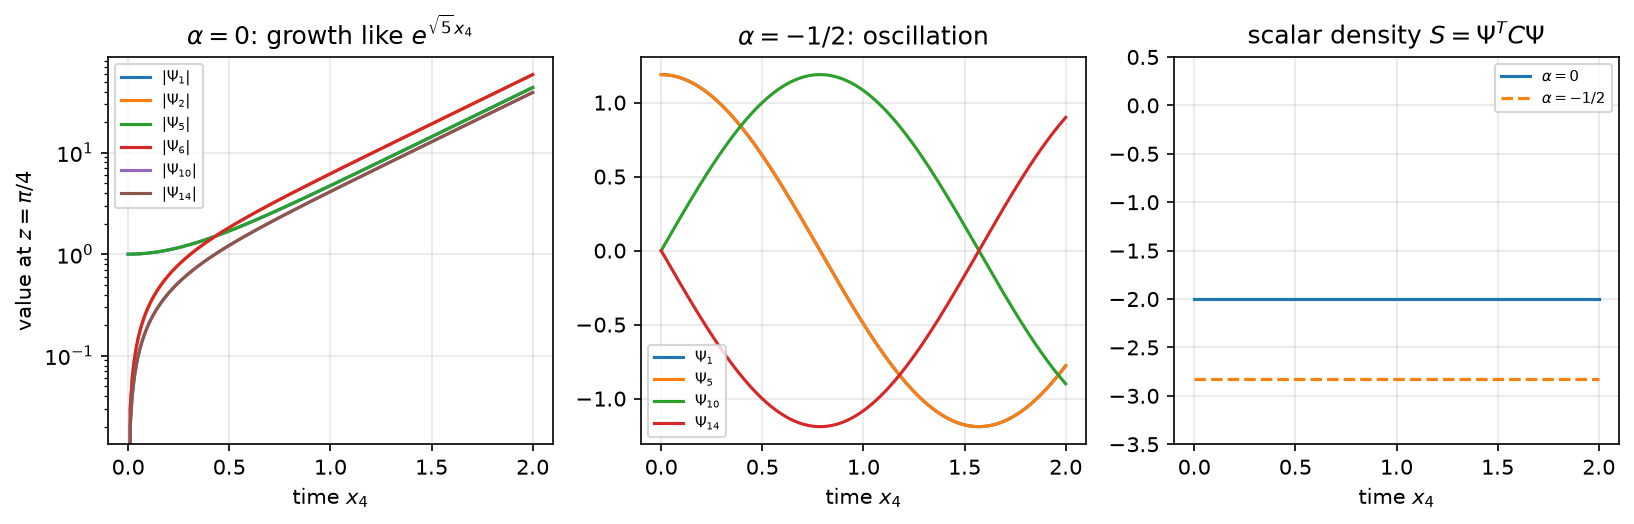

Figure 07b.5 saved as Revision/textbook/figures/07b_5_exact_solutions.png


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.6))
for A in range(16):
    if np.abs(growing[A]).max() > 1e-12:  # draw only the nonzero components
        axes[0].semilogy(xs4, np.abs(growing[A]), label=f"$|\\Psi_{{{A + 1}}}|$")
    if np.abs(oscillating[A]).max() > 1e-12:
        axes[1].plot(xs4, oscillating[A], label=f"$\\Psi_{{{A + 1}}}$")
axes[0].set_title("$\\alpha = 0$: growth like $e^{\\sqrt{5}x_4}$")
axes[1].set_title("$\\alpha = -1/2$: oscillation")
axes[2].plot(xs4, S_growing, label="$\\alpha = 0$")
axes[2].plot(xs4, S_oscillating, "--", label="$\\alpha = -1/2$")
axes[2].set_ylim(-3.5, 0.5)
axes[2].set_title("scalar density $S = \\Psi^T C\\Psi$")
for ax in axes:
    ax.set_xlabel("time $x_4$")
    ax.legend(fontsize=7)
axes[0].set_ylabel("value at $z = \\pi/4$")
fig.tight_layout()
save_figure(fig, "exact_solutions",
            "Two exact solutions $\\Psi = \\sin^\\alpha z\\,(\\cosh kx_4 + "
            "\\sinh(kx_4)/k\\,M)\\chi_0$ of the field equation with $\\lambda = 0$, "
            "for the illustration values $H = 1$, $m = 2$, $\\chi_0 = e_1 + e_5$, "
            "at $z = \\pi/4$, against the time $x_4$ from 0 to 2 (pure numbers). "
            "Left: $\\alpha = 0$, $k = \\sqrt{5}$; the nonzero components grow "
            "exponentially (logarithmic axis), the growing mode that exists without "
            "a boundary condition at $z = \\pi/2$ when $m^2 < 9H^2$. Middle: "
            "$\\alpha = -1/2$, $k = 2i$; the components oscillate. Right: the "
            "scalar density $S$ of both stays exactly constant ($-2$ and "
            "$-2/\\sin z$), because $M^TC + CM = 0$. The solutions hold for every "
            "$a_4(x_4)$.")

Finally a numerical view of non-triviality. The next cell evaluates the residual
$\gamma^{(x_4)}\partial_4\Psi + \tan z\,\gamma^{(x_8)}\partial_8\Psi + 3H\gamma^{(x_8)}
\Psi - m\Psi$ of the growing member ($\alpha = 0$, so $\partial_8\Psi = 0$) with the
exact derivative $\partial_4\Psi = (k\sinh(kx_4) + \cosh(kx_4)M)\chi_0$, once for
the full equation and twice for wrong equations: without the spin-connection term
$3H\gamma^{(x_8)}\Psi$, and with the wrong sign of the mass. The full equation is
satisfied to rounding (about $10^{-16}$ of the size of $\Psi$); the wrong ones fail
by amounts that grow with $\Psi$ (Figure 6).

PASS the full field equation holds to rounding (relative residual below 1e-12 at all 201
    times)
PASS without the term 3 H gamma^(x8) Psi the residual is 3 H |Psi|


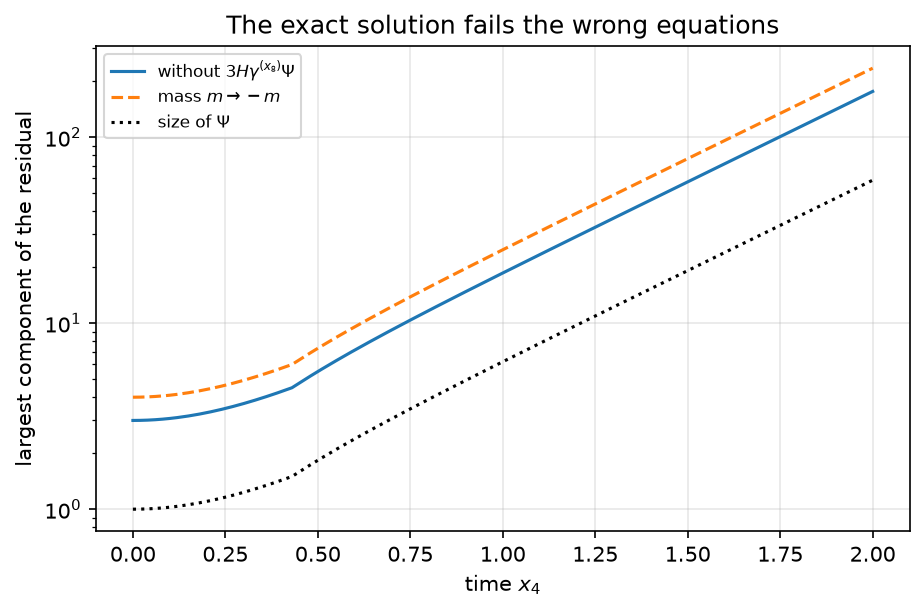

Figure 07b.6 saved as Revision/textbook/figures/07b_6_residuals.png


In [24]:
Mn = -2.0 * Gn[X4] + 3.0 * Gn[X4] @ Gn[X8]  # alpha = 0, m = 2, H = 1
kk = np.sqrt(5.0)
psi_t = np.array([(np.cosh(kk * t) * np.eye(16) + np.sinh(kk * t) / kk * Mn) @ chi_n
                  for t in xs4])
dpsi_t = np.array([(kk * np.sinh(kk * t) * np.eye(16) + np.cosh(kk * t) * Mn) @ chi_n
                   for t in xs4])
full = np.array([Gn[X4] @ dp + 3.0 * Gn[X8] @ p - 2.0 * p
                 for p, dp in zip(psi_t, dpsi_t)])
no_gravity = np.array([Gn[X4] @ dp - 2.0 * p for p, dp in zip(psi_t, dpsi_t)])
wrong_mass = np.array([Gn[X4] @ dp + 3.0 * Gn[X8] @ p + 2.0 * p
                       for p, dp in zip(psi_t, dpsi_t)])
size = np.abs(psi_t).max(axis=1)  # the size of Psi at each time
relative_full = np.abs(full).max(axis=1) / size
check(relative_full.max() < 1e-12, "the full field equation holds to rounding "
      "(relative residual below 1e-12 at all 201 times)")
check(np.allclose(np.abs(no_gravity).max(axis=1), 3.0 * size),
      "without the term 3 H gamma^(x8) Psi the residual is 3 H |Psi|")

fig, ax = plt.subplots()
ax.semilogy(xs4, np.abs(no_gravity).max(axis=1),
            label="without $3H\\gamma^{(x_8)}\\Psi$")
ax.semilogy(xs4, np.abs(wrong_mass).max(axis=1), "--", label="mass $m \\to -m$")
ax.semilogy(xs4, size, ":", color="black", label="size of $\\Psi$")
ax.set_xlabel("time $x_4$")
ax.set_ylabel("largest component of the residual")
ax.set_title("The exact solution fails the wrong equations")
ax.legend(fontsize=8)
save_figure(fig, "residuals",
            "The largest component of the residual of the growing exact solution "
            "($\\alpha = 0$, $H = 1$, $m = 2$, $\\chi_0 = e_1 + e_5$) against the "
            "time $x_4$ (logarithmic vertical axis), when it is put into two WRONG "
            "equations: the field equation without the spin-connection term "
            "$3H\\gamma^{(x_8)}\\Psi$ (solid; it equals $3H$ times the largest "
            "component of $\\Psi$, dotted) and the equation with the wrong sign of "
            "the mass (dashed). In the correct equation the residual is zero up to "
            "rounding (relative size below $10^{-12}$, not drawn on this axis). "
            "The gravitational term is needed for the solution.")

## 20. The last check

The last cell checks that the six figure files exist and prints the number of
checks that passed.

In [25]:
names = ["scale_factors", "gamma_omega_per_direction", "lagrangian_monomials",
         "coupling_map", "exact_solutions", "residuals"]
files = [f"{FIGURE_FOLDER}/07b_{k}_{name}.png" for k, name in enumerate(names, 1)]
check(all(output_file(path).is_file() for path in files),
      "all 6 figure files of this notebook exist")
all_checks_passed()

PASS all 6 figure files of this notebook exist
ALL 47 CHECKS PASSED (notebook 07b)


## 21. What this notebook showed

- The diagonal frame $f = (e^{a_4}\sin^{1/6}z\ (\times3),\ 1,\ e^{-a_4}\sin^{1/6}z\
  (\times3),\ \cot z)$ gives exactly the author's metric, with $\sqrt{|g|} = \cos z$
  independent of time: the inflation of 3-space and the deflation of the extra times
  compensate.
- The metric has 25 independent nonzero Christoffel symbols; the canonical spin
  connection has 12 nonzero components, each $a_4'$ or $H$ times a nonvanishing
  factor.
- Direction by direction, $\gamma^\mu\Omega_\mu$ has a time part $\pm\frac12a_4'
  \gamma^{(x_4)}$ that cancels between the three inflating and the three deflating
  directions, and a hidden part $\frac12H\gamma^{(x_8)}$ that adds up: $\gamma^\mu
  \Omega_\mu = 3H\gamma^{(x_8)}$ for every $a_4$.
- The Lagrangian of both fields is real, differs from the unsymmetrised form by a
  total divergence, and in this metric does not contain the spin connection at all
  ($\{\gamma^\mu, \Omega_\mu\} = 0$); written in jets it has 392 monomials for
  dirac16complex and 408 for dirac16complex00, the difference being the 16 squares
  that vanish for Grassmann numbers.
- Its Euler-Lagrange equations are the same for both statistics:
  $\gamma^\mu D_\mu\Psi = (m + \lambda S)\Psi$ and its Dirac conjugate. In the
  author's metric the 16 component equations contain the frame factors
  $e^{-a_4}\sin^{-1/6}z$, $1$, $e^{a_4}\sin^{-1/6}z$, $\tan z$ and the
  gravitational term $3H\gamma^{(x_8)}\Psi$; they agree term by term with the
  Revision formula record. Each equation couples four components across the chiral
  halves: every gamma is block off-diagonal, and the mass term and the term
  $3H\gamma^{(x_8)}$ both couple the halves $\psi_-$ and $\psi_+$.
- Solved for the time derivative, $\partial_4\Psi = -\gamma^{(x_4)}[V\Psi -
  \sum_{a\neq4}f_a^{-1}\gamma^{(a)}\partial_a\Psi - 3H\gamma^{(x_8)}\Psi]$: the
  slices $x_4 = $ const are non-characteristic, which does not by itself make the
  initial-value problem well posed (the extra-time growth rates are unbounded).
- The family $\Psi = \sin^\alpha z(\cosh kx_4 + \sinh(kx_4)/k\,M)\chi_0$ solves the
  equations exactly for every $a_4$, with constant $S$; for $\alpha = 0$ and $m^2
  < 9H^2$ it grows exponentially, and it fails the equation from which the
  spin-connection term is removed.
- Every statement that the Revision record also contains was reproduced; the scope
  of the gravitational term (frame and variable dependence) is the one stated in
  the Revision record.